In [1]:
import torch
import pandas as pd
import numpy as np

def format_pytorch_version(version):
  return version.split('+')[0]

TORCH_VERSION = format_pytorch_version(torch.__version__)
CUDA_VERSION = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'

print(f"Installing torch_geometric and its dependencies for PyTorch {TORCH_VERSION} and CUDA {CUDA_VERSION}...")
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html
!pip install -q torch_geometric
print("Installation complete.")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE

from sklearn.neighbors import kneighbors_graph
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

import matplotlib.pyplot as plt
import seaborn as sns

Installing torch_geometric and its dependencies for PyTorch 2.11.0 and CUDA cpu...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.1/682.1 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.6 MB/s eta 0:00:00
Installation complete.


Install torch+torch_geometric sesuai versi CUDA/CPU yang terdeteksi, agar notebook bisa jalan di colab dengan bantuan akses internet.

In [2]:
df = pd.read_csv('obesity.csv', sep=';', decimal=',')
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21,Female,1.62,64,no,no,2,3,no,no,2,yes,0,1,Sometimes,Public_Transportation,Normal_Weight
1,21,Female,1.52,56,Sometimes,no,3,3,yes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,23,Male,1.80,77,Frequently,no,2,3,no,no,2,yes,2,1,Sometimes,Public_Transportation,Normal_Weight
3,27,Male,1.80,87,Frequently,no,3,3,no,no,2,no,2,0,Sometimes,Walking,Overweight_Level_I
4,22,Male,1.78,90,Sometimes,no,2,1,no,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


karena format data berbentuk excel atau dataset ini formatnya eropa, sehingga harus ada seperator titik-koma dan koma-desimal agar semua kolom numerik jadi 1 kolom teks

In [3]:
df.tail()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
2106,20,Female,1.71,132,Sometimes,yes,3,3,no,no,1,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_III
2107,21,Female,1.75,134,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_III
2108,22,Female,1.75,134,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_III
2109,24,Female,1.74,133,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_III
2110,23,Female,1.74,133,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_III


melakukan pengecekan 5 baris terakhir yang ada pada dataset

In [4]:
df.rename(columns={
    'Gender': 'jenis_kelamin',
    'Age': 'umur',
    'family_history_with_overweight': 'riwayat_obesitas',
    'FAVC': 'kat_makan_berkalori',
    'FCVC': 'kat_makan_sayur',
    'NCP': 'jml_makan_utama',
    'CAEC': 'kat_makan_cemilan',
    'SMOKE': 'kat_merokok',
    'CH2O': 'jml_konsum_air',
    'SCC': 'monitoring_kalori',
    'FAF': 'frek_aktivitas_fisik',
    'TUE': 'durasi_penggunaan_gadget',
    'CALC': 'kat_konsum_alkohol',
    'MTRANS': 'jenis_transportasi',
    'NObeyesdad': 'label'
}, inplace=True)
df.sample(5)

,umur,jenis_kelamin,Height,Weight,kat_konsum_alkohol,kat_makan_berkalori,kat_makan_sayur,jml_makan_utama,monitoring_kalori,kat_merokok,jml_konsum_air,riwayat_obesitas,frek_aktivitas_fisik,durasi_penggunaan_gadget,kat_makan_cemilan,jenis_transportasi,label
67,23,Male,1.65,95,Frequently,yes,2,3,no,no,2,yes,0,1,Always,Automobile,Obesity_Type_I
1105,22,Male,1.82,96,Sometimes,yes,1,2,no,no,2,yes,1,1,Sometimes,Public_Transportation,Overweight_Level_II
1580,24,Male,1.78,120,Sometimes,yes,2,3,no,no,2,yes,1,0,Sometimes,Public_Transportation,Obesity_Type_II
1709,20,Male,1.62,103,no,yes,2,1,no,no,1,yes,0,0,Sometimes,Public_Transportation,Obesity_Type_II
289,19,Male,1.88,79,Sometimes,no,2,3,no,no,3,no,3,0,Sometimes,Automobile,Normal_Weight


mengubah nama semua kolom singkatan menjadi nama deskriptif berbahasa Indonesia, disesuaikan dengan atribut pada ERD (Entity Relationship Diagram) hasil sempro, agar konsisten dengan rancangan basis data

## Kamus Data — Penjelasan Setiap Kolom

Setelah proses rename, dataset punya **14 fitur (variabel bebas)** + **1 kolom label asli** + **1 kolom target hasil mapping**. Berikut penjelasan tiap kolom:

| Kolom | Nama Asli | Tipe | Nilai / Satuan | Penjelasan |
|---|---|---|---|---|
| `umur` | Age | Numerik | Tahun (≥18) | Usia responden, dibatasi dewasa sesuai batasan penelitian |
| `jenis_kelamin` | Gender | Kategorikal **nominal** | Female / Male | Jenis kelamin, tidak ada tingkatan antar kategori |
| `riwayat_obesitas` | family_history_with_overweight | Kategorikal biner | yes / no | Apakah ada anggota keluarga yang overweight/obesitas |
| `kat_makan_berkalori` | FAVC | Kategorikal biner | yes / no | Kebiasaan sering makan makanan tinggi kalori |
| `kat_makan_sayur` | FCVC | Numerik (skala) | 1 (jarang) – 3 (sering) | Frekuensi konsumsi sayur |
| `jml_makan_utama` | NCP | Numerik | 1 – 4 | Jumlah makan besar/utama per hari |
| `kat_makan_cemilan` | CAEC | Kategorikal **ordinal** | no < Sometimes < Frequently < Always | Kebiasaan ngemil di luar jam makan utama — **ada tingkatan asli**, tapi di-one-hot supaya konsisten dengan seluruh variabel kategorikal lain (lihat diskusi di bawah) |
| `kat_merokok` | SMOKE | Kategorikal biner | yes / no | Kebiasaan merokok |
| `jml_konsum_air` | CH2O | Numerik (skala) | 1 (sedikit) – 3 (banyak) | Konsumsi air harian |
| `monitoring_kalori` | SCC | Kategorikal biner | yes / no | Apakah memantau kalori yang dikonsumsi |
| `frek_aktivitas_fisik` | FAF | Numerik (skala) | 0 (tidak pernah) – 3 (sering) | Frekuensi aktivitas fisik per minggu |
| `durasi_penggunaan_gadget` | TUE | Numerik (skala) | 0 (sedikit) – 2 (banyak) | Waktu penggunaan gadget/layar per hari |
| `kat_konsum_alkohol` | CALC | Kategorikal **ordinal** | no < Sometimes < Frequently < Always | Frekuensi konsumsi alkohol — sama seperti `kat_makan_cemilan`, ada tingkatan asli tapi di-one-hot untuk konsistensi |
| `jenis_transportasi` | MTRANS | Kategorikal **nominal** | Automobile, Bike, Motorbike, Public_Transportation, Walking | Moda transportasi utama sehari-hari — murni beda jenis, tidak ada tingkatan |
| `label` | NObeyesdad | Target asli (7 kelas) | Insufficient_Weight ... Obesity_Type_III | Kategori WHO berdasarkan BMI, dihitung dari Height & Weight (yang kemudian di-drop dari fitur, lihat cell 22) |
| `hasil_prediksi` | — (hasil mapping) | Target final (3 kelas) | Rendah / Sedang / Tinggi | Hasil mapping 7 kelas `label` → 3 tingkat risiko (lihat `risk_map`), inilah target yang diprediksi model |

**Catatan soal `kat_makan_cemilan` & `kat_konsum_alkohol`:** dua kolom ini sebenarnya *ordinal* (ada urutan "seberapa sering"), berbeda dari `jenis_transportasi` yang murni nominal (beda jenis, bukan beda tingkat). Di notebook ini keduanya tetap di-**one-hot** bersama variabel kategorikal lain, karena itu yang ditulis di metodologi (BAB IV) dan konsisten dengan pipeline acuan. Ini pilihan yang valid secara metodologi (tidak salah), meskipun bukan satu-satunya pilihan — pendekatan ordinal murni untuk 2 kolom ini juga sama-sama sah kalau suatu saat mau dieksplorasi sebagai perbandingan/pengembangan.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   umur                      2111 non-null   int64  
 1   jenis_kelamin             2111 non-null   object 
 2   Height                    2111 non-null   float64
 3   Weight                    2111 non-null   int64  
 4   kat_konsum_alkohol        2111 non-null   object 
 5   kat_makan_berkalori       2111 non-null   object 
 6   kat_makan_sayur           2111 non-null   int64  
 7   jml_makan_utama           2111 non-null   int64  
 8   monitoring_kalori         2111 non-null   object 
 9   kat_merokok               2111 non-null   object 
 10  jml_konsum_air            2111 non-null   int64  
 11  riwayat_obesitas          2111 non-null   object 
 12  frek_aktivitas_fisik      2111 non-null   int64  
 13  durasi_penggunaan_gadget  2111 non-null   int64  
 14  kat_maka

mengecek tipe data dan jumlah non null setiap kolom

In [6]:
df.isnull().sum()

,0
umur,0
jenis_kelamin,0
Height,0
Weight,0
kat_konsum_alkohol,0
kat_makan_berkalori,0
kat_makan_sayur,0
jml_makan_utama,0
monitoring_kalori,0
kat_merokok,0


cek missing value. ternyata semua hasilnya 0, berarti tidak ada kolom yang tidak memiliki nilai

In [7]:
df.duplicated().sum()

np.int64(281)

mengecek duplikat, ternyata terdapat duplikat sekitar 281 baris

In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

melakukan penghapusan semua data yang terduplikat, sehingga ketika kode ini dijalankan hasilnya sudah 0

In [9]:
df.shape

(1830, 17)

melihat isian data, terdapat 1830 baris dan 17 kolom

In [10]:
df.describe()

,umur,Height,Weight,kat_makan_sayur,jml_makan_utama,jml_konsum_air,frek_aktivitas_fisik,durasi_penggunaan_gadget
count,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000,1830.000000
mean,23.971038,1.702831,85.574317,2.178689,2.515301,1.700000,0.766120,0.410383
std,6.560542,0.095253,43.150197,0.581550,0.836259,0.601756,0.852071,0.596510
min,14.000000,1.450000,10.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.000000,1.630000,64.000000,2.000000,2.000000,1.000000,0.000000,0.000000
50%,22.000000,1.700000,81.000000,2.000000,3.000000,2.000000,1.000000,0.000000
75%,26.000000,1.770000,104.000000,3.000000,3.000000,2.000000,1.000000,1.000000
max,61.000000,1.980000,975.000000,3.000000,4.000000,3.000000,3.000000,2.000000


mengecek statistik deskriptif dari data pada kolom numerik

In [11]:
# Kolom kategorikal
categorical_cols = df.select_dtypes(include=['object']).columns
print("Kolom Kategorikal:", categorical_cols)

# Kolom numerik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Kolom Numerik:", numerical_cols)

Kolom Kategorikal: Index(['jenis_kelamin', 'kat_konsum_alkohol', 'kat_makan_berkalori',
       'monitoring_kalori', 'kat_merokok', 'riwayat_obesitas',
       'kat_makan_cemilan', 'jenis_transportasi', 'label'],
      dtype='object')
Kolom Numerik: Index(['umur', 'Height', 'Weight', 'kat_makan_sayur', 'jml_makan_utama',
       'jml_konsum_air', 'frek_aktivitas_fisik', 'durasi_penggunaan_gadget'],
      dtype='object')


memisahkan kolom kategorikal dan numerik yang berguna untuk mengetahui kolom mana saja yang perlu di encode

In [12]:
df.columns = df.columns.str.strip()
df = df[df['umur'] >= 18].reset_index(drop=True)

df = df.drop(columns=['Height', 'Weight'], errors='ignore')
df.shape

(1722, 15)

menyesuaikan dari batasan proposal, bahwa hanya fokus pada populasi dewasa, sehingga kolom yang berusia 18 tahun kebawah akan di hapus, kemudian menghapus kolom height san weight agar model tidak curang dan memakai bmi langsung, fokus nya ke pola hidup

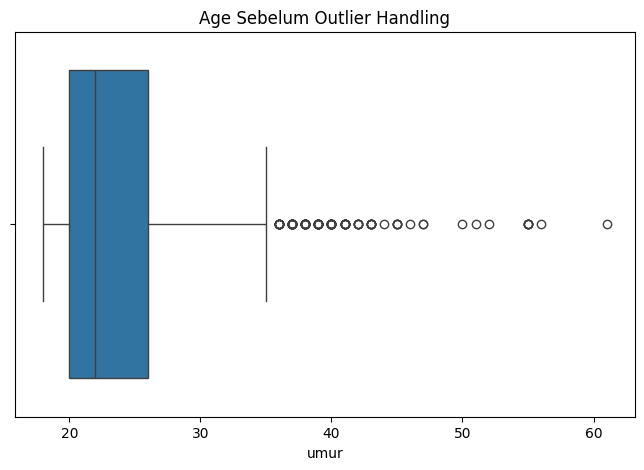

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['umur'])
plt.title("Age Sebelum Outlier Handling")
plt.show()

Boxplot umur untuk cek outlier. Notebook menampilkan tapi tidak melakukan removal outlier setelah ini hanya visual

In [14]:
print(df['umur'].describe())

count    1722.000000
mean       24.427410
std         6.495581
min        18.000000
25%        20.000000
50%        22.000000
75%        26.000000
max        61.000000
Name: umur, dtype: float64


hanya melihat informasi deskripsi dari kolom umur

In [15]:
risk_map = {
'Insufficient_Weight': 'Rendah', 'Normal_Weight': 'Rendah',
    'Overweight_Level_I': 'Sedang', 'Overweight_Level_II': 'Sedang',
    'Obesity_Type_I': 'Tinggi', 'Obesity_Type_II': 'Tinggi', 'Obesity_Type_III': 'Tinggi'
}
df['hasil_prediksi'] = df['label'].map(risk_map)

mengubah target kolom label dari yang awalnya 7 kelas untuk mengetahui tingkatan obesitas, sehingga menjadi 3 kelas untuk mengetahui tingkatan risiko terkena obesitas. Kolom hasil mapping ini diberi nama `hasil_prediksi`, sesuai atribut pada entitas `Prediksi_Risiko` di ERD

/tmp/ipykernel_1492/473611281.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', ax=ax[0], palette='magma',
/tmp/ipykernel_1492/473611281.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hasil_prediksi', ax=ax[1], palette='viridis',


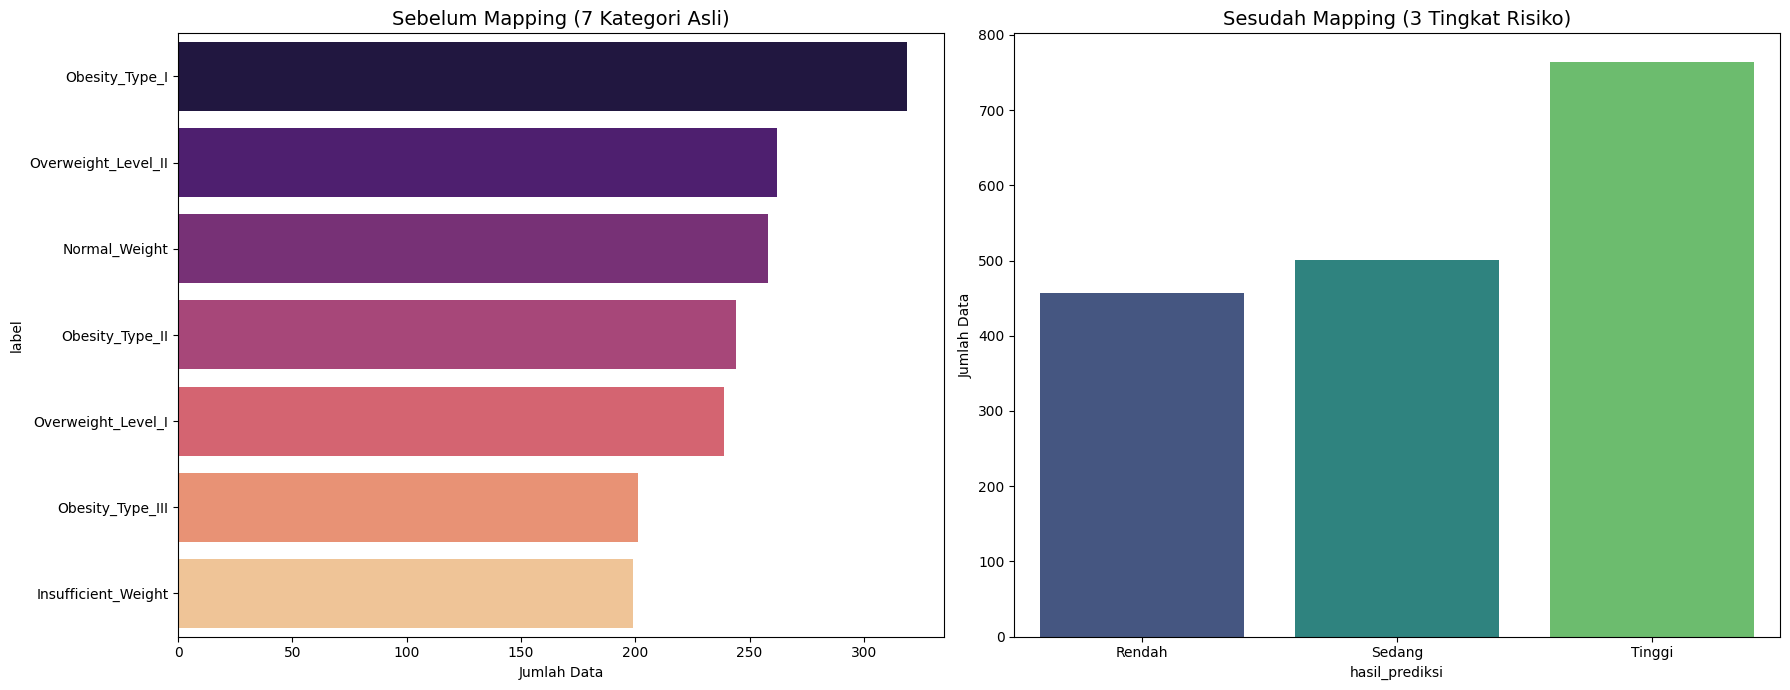

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.countplot(data=df, y='label', ax=ax[0], palette='magma',
              order=df['label'].value_counts().index)
ax[0].set_title('Sebelum Mapping (7 Kategori Asli)', fontsize=14)
ax[0].set_xlabel('Jumlah Data')

sns.countplot(data=df, x='hasil_prediksi', ax=ax[1], palette='viridis',
              order=['Rendah', 'Sedang', 'Tinggi'])
ax[1].set_title('Sesudah Mapping (3 Tingkat Risiko)', fontsize=14)
ax[1].set_ylabel('Jumlah Data')

plt.tight_layout()
plt.show()

Bar chart perbandingan distribusi sebelum (7 kelas) vs sesudah (3 kelas) mapping.

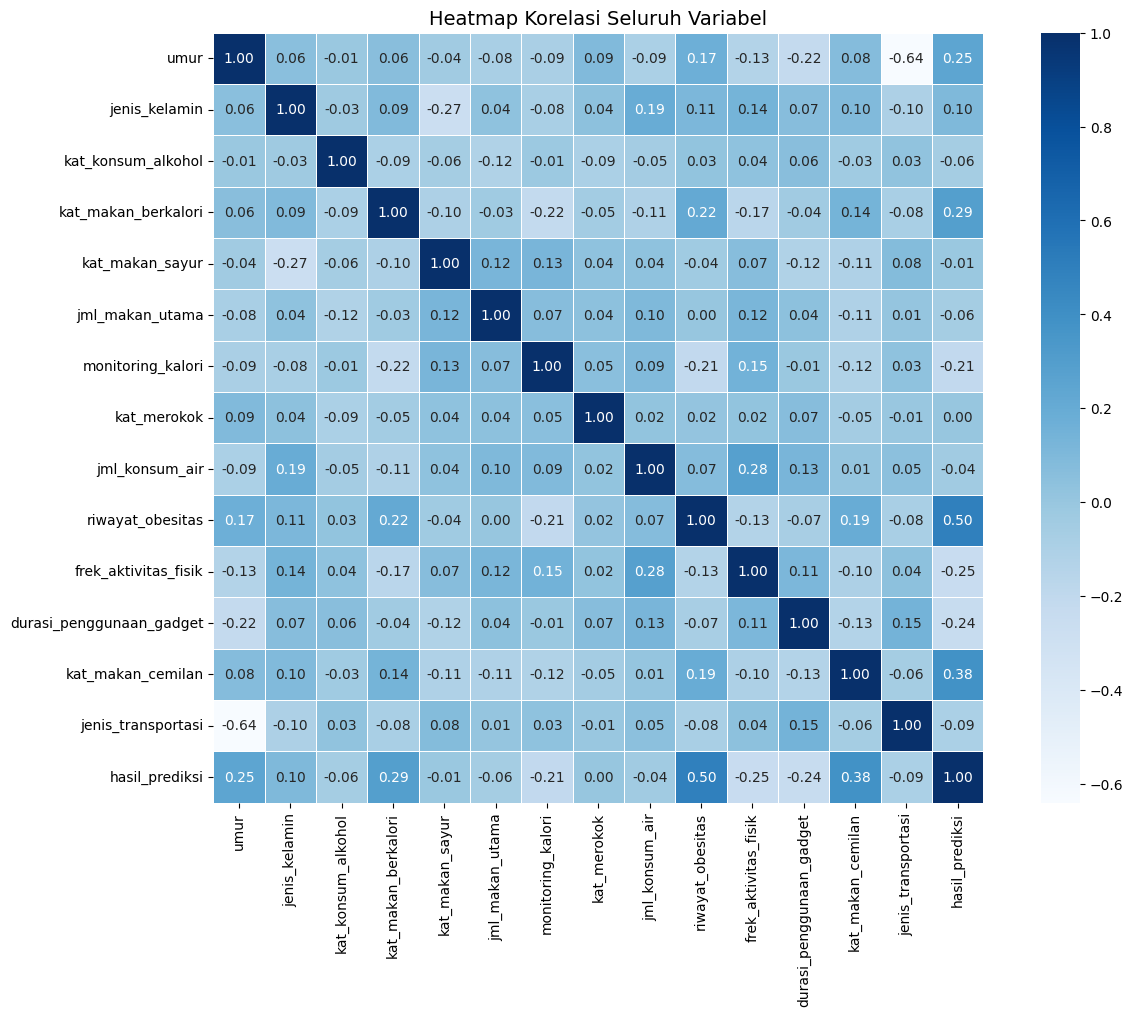

In [17]:
df_encoded = df.drop(columns=['label']).copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(15, 10))
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Seluruh Variabel', fontsize=14)
plt.show()

(LabelEncoder untuk semua kolom teks), lalu heatmap korelasi seluruh variabel. Ini satu-satunya cell yang benar-benar menjawab "hubungan antar kolom" secara harfiah (bukan graf).

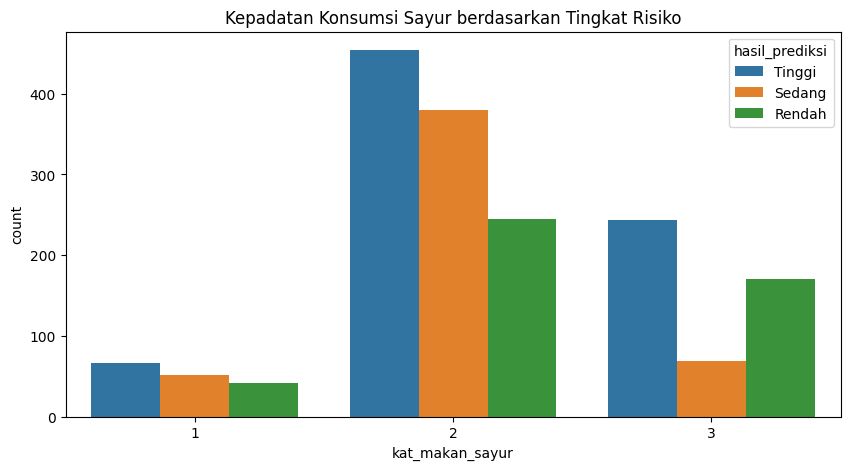

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot( x='kat_makan_sayur', hue='hasil_prediksi', data=df)
plt.title('Kepadatan Konsumsi Sayur berdasarkan Tingkat Risiko')
plt.show()

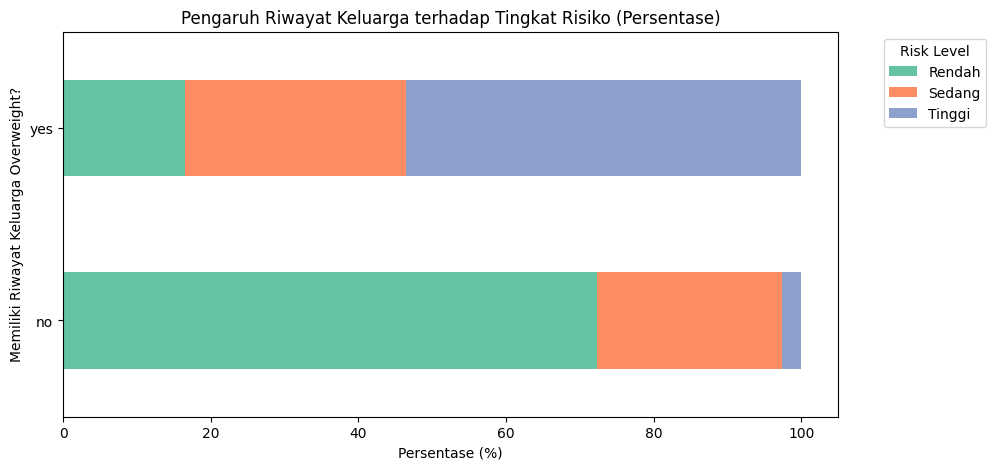

In [19]:
ct = pd.crosstab(df['riwayat_obesitas'], df['hasil_prediksi'], normalize='index') * 100

ct.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 5),
    color=sns.color_palette('Set2'))

plt.title('Pengaruh Riwayat Keluarga terhadap Tingkat Risiko (Persentase)')
plt.xlabel('Persentase (%)')
plt.ylabel('Memiliki Riwayat Keluarga Overweight?')
plt.legend(title='Risk Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

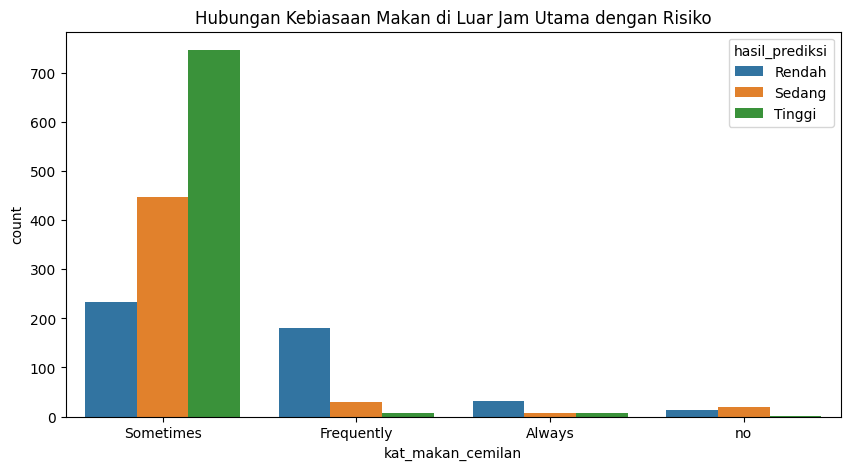

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='kat_makan_cemilan', hue='hasil_prediksi', data=df)
plt.title('Hubungan Kebiasaan Makan di Luar Jam Utama dengan Risiko')
plt.show()

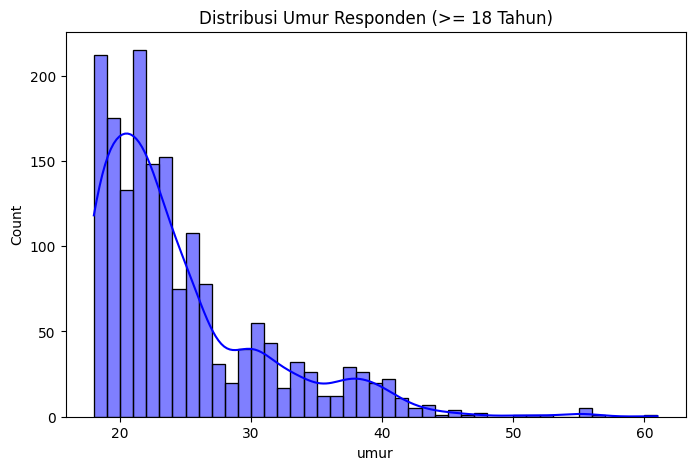

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['umur'], kde=True, color='blue')
plt.title('Distribusi Umur Responden (>= 18 Tahun)')
plt.show()

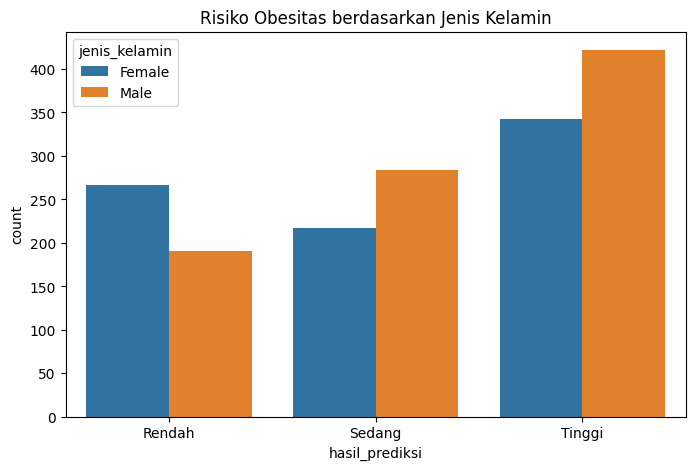

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='hasil_prediksi', hue='jenis_kelamin', data=df)
plt.title('Risiko Obesitas berdasarkan Jenis Kelamin')
plt.show()

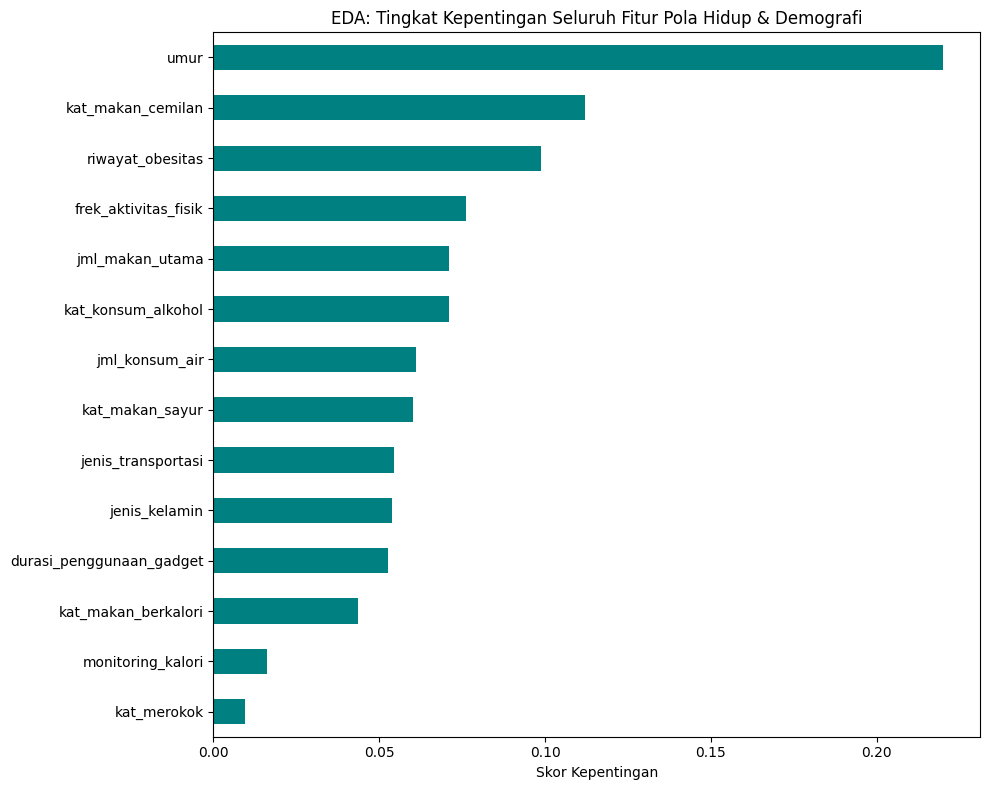

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

X_eda = df_encoded.drop(columns=['hasil_prediksi'])
y_eda = df_encoded['hasil_prediksi']

model_eda = RandomForestClassifier(random_state=42)
model_eda.fit(X_eda, y_eda)

# 3. Visualisasi SEMUA Fitur
feat_importances = pd.Series(model_eda.feature_importances_, index=X_eda.columns)

plt.figure(figsize=(10, 8))
feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title('EDA: Tingkat Kepentingan Seluruh Fitur Pola Hidup & Demografi')
plt.xlabel('Skor Kepentingan')
plt.tight_layout()
plt.show()

### Insight — Kolom Apa yang Menentukan Kategori Risiko, dan Apa yang Memengaruhinya?

**Kolom penentu kategori (target):** kategori `hasil_prediksi` (Rendah/Sedang/Tinggi) **bukan** dihitung langsung dari kombinasi fitur di X. Kolom itu adalah hasil *mapping* dari `label` (kolom asli `NObeyesdad`), yaitu kategori WHO 7-kelas yang di dataset sumbernya dihitung dari **BMI = Weight / Height²**. Alurnya:

`Height, Weight → BMI → NObeyesdad (7 kelas WHO) → risk_map → hasil_prediksi (3 kelas)`

Karena `Height` dan `Weight` sengaja **di-drop** dari fitur (cell "Kolom Kategorikal/Numerik" di atas), model **tidak** melihat BMI secara langsung — model justru dipaksa belajar memprediksi risiko dari **pola gaya hidup** saja. Ini konsisten dengan fokus proyek ("Fokus pola hidup sesuai proposal").

**Apa yang paling memengaruhi (berdasarkan data aktual, bukan asumsi):**

Dihitung dengan dua cara pada data yang sama (`df_encoded`, sebelum augmentasi/SMOTE) agar saling mengonfirmasi:

- **Korelasi (Pearson) terhadap `hasil_prediksi`** menonjolkan arah pengaruh:
  - `riwayat_obesitas` (+0.50) — riwayat keluarga overweight adalah prediktor terkuat.
  - `kat_makan_cemilan`/CAEC (+0.38) dan `kat_makan_berkalori`/FAVC (+0.29) — kebiasaan makan tinggi kalori/ngemil.
  - `umur` (+0.25) — makin tua, risiko cenderung naik.
  - `frek_aktivitas_fisik`/FAF (−0.25) dan `durasi_penggunaan_gadget`/TUE (−0.24) — makin aktif secara fisik & makin sedikit waktu layar, makin rendah risikonya.
  - `monitoring_kalori`/SCC (−0.21) — orang yang memantau kalori cenderung berisiko lebih rendah.
- **Feature importance (Random Forest)** menonjolkan kekuatan prediktif gabungan (termasuk interaksi non-linear): `umur` paling tinggi, disusul `kat_makan_cemilan`, `riwayat_obesitas`, `frek_aktivitas_fisik`, `jml_makan_utama`, `kat_konsum_alkohol`.

Kesimpulannya konsisten: **riwayat keluarga, kebiasaan ngemil/makanan tinggi kalori, usia, dan tingkat aktivitas fisik** adalah pendorong utama kategori risiko — bukan `jenis_kelamin`, `kat_merokok`, atau `jml_konsum_air`, yang pengaruhnya kecil.


KORELASI (Pearson) SETIAP FITUR TERHADAP hasil_prediksi
(diurutkan berdasarkan kekuatan pengaruh, +/- menandakan arah)
  riwayat_obesitas      : +0.500  (hasil_prediksi cenderung naik)
  kat_makan_cemilan     : +0.379  (hasil_prediksi cenderung naik)
  kat_makan_berkalori   : +0.295  (hasil_prediksi cenderung naik)
  umur                  : +0.250  (hasil_prediksi cenderung naik)
  frek_aktivitas_fisik  : -0.246  (hasil_prediksi cenderung turun)
  durasi_penggunaan_gadget: -0.240  (hasil_prediksi cenderung turun)
  monitoring_kalori     : -0.208  (hasil_prediksi cenderung turun)
  jenis_kelamin         : +0.100  (hasil_prediksi cenderung naik)
  jenis_transportasi    : -0.090  (hasil_prediksi cenderung turun)
  jml_makan_utama       : -0.060  (hasil_prediksi cenderung turun)
  kat_konsum_alkohol    : -0.058  (hasil_prediksi cenderung turun)
  jml_konsum_air        : -0.042  (hasil_prediksi cenderung turun)
  kat_makan_sayur       : -0.009  (hasil_prediksi cenderung turun)
  kat_merokok

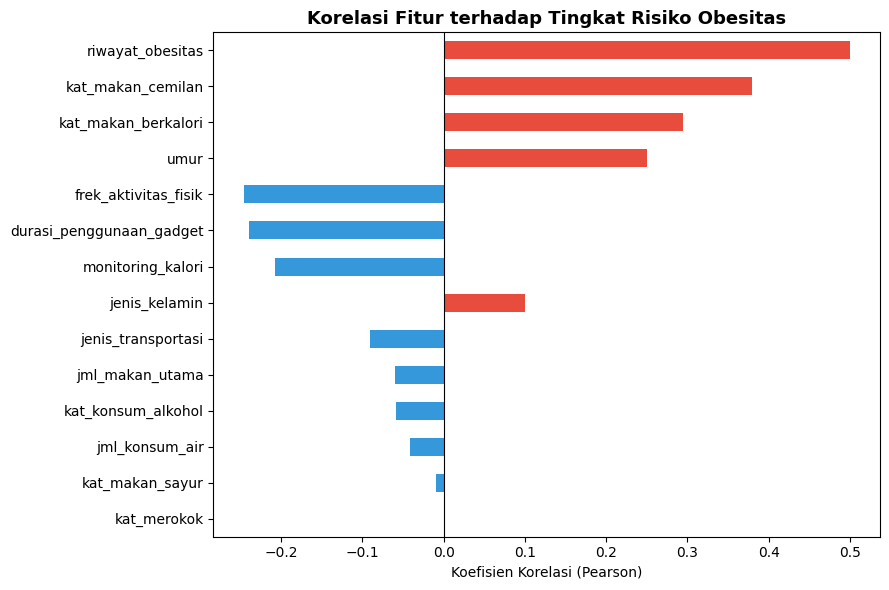

In [24]:
# ============================================================
# INSIGHT TAMBAHAN: Korelasi & Feature Importance vs hasil_prediksi
# (melengkapi feature importance yang sudah ada di atas dengan
#  korelasi Pearson, agar arah pengaruh -- naik/turun -- terlihat)
# ============================================================
import pandas as pd

corr_risk = df_encoded.corr(numeric_only=True)['hasil_prediksi'].drop('hasil_prediksi')
corr_risk_sorted = corr_risk.reindex(corr_risk.abs().sort_values(ascending=False).index)

print('=' * 60)
print('KORELASI (Pearson) SETIAP FITUR TERHADAP hasil_prediksi')
print('(diurutkan berdasarkan kekuatan pengaruh, +/- menandakan arah)')
print('=' * 60)
for col, val in corr_risk_sorted.items():
    arah = 'naik' if val > 0 else 'turun'
    print(f'  {col:22s}: {val:+.3f}  (hasil_prediksi cenderung {arah})')

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_risk_sorted.values]
corr_risk_sorted.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur terhadap Tingkat Risiko Obesitas', fontsize=13, fontweight='bold')
plt.xlabel('Koefisien Korelasi (Pearson)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('korelasi_risk_level.png', dpi=300, bbox_inches='tight')
plt.show()


# Preprocessing

In [25]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [26]:
# FIX: X dibangun dari df ASLI (bukan df_encoded), lalu kolom kategorikal
# di-ONE-HOT (bukan LabelEncoder ordinal), supaya konsisten dengan metode
# One-Hot Encoding yang dijelaskan di BAB IV. df_encoded (ordinal) tetap
# dipakai HANYA untuk heatmap korelasi EDA di atas (cell sebelumnya), tidak
# lagi dipakai sebagai input model.
categorical_cols_X = (
    df.drop(columns=['label', 'hasil_prediksi'])
      .select_dtypes(include=['object'])
      .columns.tolist()
)

X = pd.get_dummies(
    df.drop(columns=['label', 'hasil_prediksi']),
    columns=categorical_cols_X,
    drop_first=False
)
# get_dummies menghasilkan tipe bool -> ubah ke 0/1 (int) supaya konsisten
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

y = df['hasil_prediksi']

print(f'Kolom kategorikal yang di-one-hot: {categorical_cols_X}')
print(f'Jumlah kolom X sebelum one-hot : {df.drop(columns=["label","hasil_prediksi"]).shape[1]}')
print(f'Jumlah kolom X sesudah one-hot : {X.shape[1]}')

Kolom kategorikal yang di-one-hot: ['jenis_kelamin', 'kat_konsum_alkohol', 'kat_makan_berkalori', 'monitoring_kalori', 'kat_merokok', 'riwayat_obesitas', 'kat_makan_cemilan', 'jenis_transportasi']
Jumlah kolom X sebelum one-hot : 14
Jumlah kolom X sesudah one-hot : 29


In [27]:
import pandas as pd
pd.set_option('display.max_columns', None)
print(df_encoded.head())

   umur  jenis_kelamin  kat_konsum_alkohol  kat_makan_berkalori  \
0    21              0                   3                    0   
1    21              0                   2                    0   
2    23              1                   1                    0   
3    27              1                   1                    0   
4    22              1                   2                    0   

   kat_makan_sayur  jml_makan_utama  monitoring_kalori  kat_merokok  \
0                2                3                  0            0   
1                3                3                  1            1   
2                2                3                  0            0   
3                3                3                  0            0   
4                2                1                  0            0   

   jml_konsum_air  riwayat_obesitas  frek_aktivitas_fisik  \
0               2                 1                     0   
1               3                 1             

In [28]:
for col in df.columns:
    print(f"\n{"="*40}")
    print(f"Kolom: {col}")
    print(f"{"="*40}")

    print("Sebelum Encoding / Nilai Asli:")
    print(df[col].unique())

    print("Sesudah Encoding:")

    if col == 'label' and 'hasil_prediksi' in df_encoded.columns:
        print(df_encoded['hasil_prediksi'].unique())
    elif col == 'hasil_prediksi' and 'hasil_prediksi' in df_encoded.columns:
        print(df_encoded['hasil_prediksi'].unique())
    elif col in df_encoded.columns:
        print(df_encoded[col].unique())
    else:
        print(f"Kolom '{col}' tidak ditemukan di df_encoded (Mungkin sudah di-drop/diubah nama).")


Kolom: umur
Sebelum Encoding / Nilai Asli:
[21 23 27 22 29 24 26 41 30 52 20 19 31 39 25 55 38 18 61 44 34 36 32 35
 40 45 33 51 56 28 37 42 50 43 46 47]
Sesudah Encoding:
[21 23 27 22 29 24 26 41 30 52 20 19 31 39 25 55 38 18 61 44 34 36 32 35
 40 45 33 51 56 28 37 42 50 43 46 47]

Kolom: jenis_kelamin
Sebelum Encoding / Nilai Asli:
['Female' 'Male']
Sesudah Encoding:
[0 1]

Kolom: kat_konsum_alkohol
Sebelum Encoding / Nilai Asli:
['no' 'Sometimes' 'Frequently' 'Always']
Sesudah Encoding:
[3 2 1 0]

Kolom: kat_makan_berkalori
Sebelum Encoding / Nilai Asli:
['no' 'yes']
Sesudah Encoding:
[0 1]

Kolom: kat_makan_sayur
Sebelum Encoding / Nilai Asli:
[2 3 1]
Sesudah Encoding:
[2 3 1]

Kolom: jml_makan_utama
Sebelum Encoding / Nilai Asli:
[3 1 4 2]
Sesudah Encoding:
[3 1 4 2]

Kolom: monitoring_kalori
Sebelum Encoding / Nilai Asli:
['no' 'yes']
Sesudah Encoding:
[0 1]

Kolom: kat_merokok
Sebelum Encoding / Nilai Asli:
['no' 'yes']
Sesudah Encoding:
[0 1]

Kolom: jml_konsum_air
Sebelum Enc

In [29]:
# FIX: encoding kategorikal untuk X sekarang sudah dilakukan dengan
# one-hot di cell sebelumnya (pd.get_dummies), jadi loop LabelEncoder
# ordinal yang lama TIDAK dipakai lagi di sini (supaya kategori nominal
# tidak diberi urutan palsu). Baris ini hanya verifikasi: harus 0 kolom
# object yang tersisa di X.
sisa_kolom_object = X.select_dtypes(include=['object']).columns.tolist()
print(f'Kolom object tersisa di X (harus kosong): {sisa_kolom_object}')
print(f'Shape X akhir (numerik + one-hot): {X.shape}')

Kolom object tersisa di X (harus kosong): []
Shape X akhir (numerik + one-hot): (1722, 29)


In [30]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le_label = LabelEncoder()
le_label.fit(['Rendah', 'Sedang', 'Tinggi'])
y_encoded = y.copy()

print('Mapping Label:')
for i, cls in enumerate(le_label.classes_):
    print(f'  {i} -> {cls}')

print(f'\nShape X: {X.shape}')
print(f'Shape y_encoded: {y_encoded.shape}')
print(f'Distribusi kelas sebelum SMOTE:\n{pd.Series(y_encoded).value_counts().sort_index()}')

Mapping Label:
  0 -> Rendah
  1 -> Sedang
  2 -> Tinggi

Shape X: (1722, 29)
Shape y_encoded: (1722,)
Distribusi kelas sebelum SMOTE:
hasil_prediksi
Rendah    457
Sedang    501
Tinggi    764
Name: count, dtype: int64


## Pipeline Model — Augmentasi + SMOTE + GraphSAGE

Susunan lengkap pipeline yang dipakai untuk melatih model final:

1. **Augmentasi Data** — Tambah data sintetis per kelas dengan Gaussian noise pada fitur numerik. Kolom kategorik tetap agar kombinasi tetap realistis. Kelas Sedang mendapat porsi augmentasi ekstra karena polanya paling ambigu (mudah tertukar ke Rendah atau Tinggi).
2. **Mapping 7 → 3 Risiko** — Setelah augmentasi, mapping ke Rendah/Sedang/Tinggi (`hasil_prediksi`).
3. **Encoding & Scaling** — Label Encode kolom kategorik, RobustScaler untuk kolom numerik.
4. **SMOTE** — Dilakukan sekali pada seluruh data (sesuai arahan dosen pembimbing) untuk menyeimbangkan 3 kelas secara sempurna.
5. **Split 80/20** — Setelah SMOTE, baru split train/test dengan stratify agar proporsi tiap kelas tetap terjaga di kedua sisi.
6. **Bangun Graf KNN** — Setiap individu jadi node, edge dibangun berdasarkan cosine similarity antar fitur gaya hidup.
7. **Training GraphSAGE** — hyperparameter yang dipakai adalah hasil tuning Optuna (lihat penjelasan lengkap sebelum training), dengan class weight tambahan untuk kelas Sedang.
8. **Evaluasi** — Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix pada data testing.

> `Height` dan `Weight` tetap dihapus dari fitur. Fokus pola hidup sesuai proposal.

Fungsi-fungsi inti (`build_knn_graph`, class `GraphSAGE`, `predict_with_graph`) didefinisikan dan diuji lebih dulu (unit test) sebelum dipakai membangun pipeline training di bawah.


In [31]:
import torch
from sklearn.neighbors import NearestNeighbors

try:
    import torch_geometric
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'torch_geometric'], check=True)

from torch_geometric.data import Data

def build_knn_graph(features, k=5):
    knn = NearestNeighbors(n_neighbors=k+1, metric='cosine')
    knn.fit(features)
    distances, indices = knn.kneighbors(features)

    edge_list = []
    for i in range(len(features)):
        for j in indices[i][1:]:
            edge_list.append([i, j])
            edge_list.append([j, i])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    edge_index = torch.unique(edge_index, dim=1)
    return edge_index, knn

print('Fungsi build_knn_graph siap dipakai (graf kNN berbasis cosine similarity).')


Fungsi build_knn_graph siap dipakai (graf kNN berbasis cosine similarity).


In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.bn1   = torch.nn.BatchNorm1d(hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn2   = torch.nn.BatchNorm1d(hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, hidden_dim // 2)
        self.bn3   = torch.nn.BatchNorm1d(hidden_dim // 2)
        self.conv4 = SAGEConv(hidden_dim // 2, output_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv4(x, edge_index)
        return x

    def get_embeddings(self, x, edge_index):
        x = self.conv1(x, edge_index); x = self.bn1(x); x = F.elu(x)
        x = self.conv2(x, edge_index); x = self.bn2(x); x = F.elu(x)
        x = self.conv3(x, edge_index); x = self.bn3(x); x = F.elu(x)
        return x

print('Class GraphSAGE (4 layer, ELU, BatchNorm) siap dipakai.')


Class GraphSAGE (4 layer, ELU, BatchNorm) siap dipakai.


### Kenapa GraphSAGE, Bukan GCN/GAT/MLP Biasa?

1. **Graf di sini bukan graf sosial asli, tapi graf kemiripan (kNN cosine)** — dibangun oleh `build_knn_graph`. Tiap "orang" jadi tetangga orang lain yang polanya mirip. GraphSAGE dirancang tepat untuk kasus ini: ia **mengagregasi fitur dari tetangga** (default: rata-rata) lalu digabung dengan fitur node itu sendiri, sehingga prediksi seseorang ikut mempertimbangkan pola gaya hidup orang-orang yang mirip dengannya — bukan hanya datanya sendiri seperti MLP biasa.
2. **Inductive, bukan transductive.** GCN klasik butuh graf yang *tetap/lengkap* saat training maupun inference — kalau ada data baru (test set), seharusnya retrain ulang di graf yang membesar. GraphSAGE belajar sebuah *fungsi agregasi* yang bisa langsung diterapkan ke node baru cukup dengan menyambungkannya ke graf (persis yang dilakukan `predict_with_graph`: gabungkan `X_train` + `X_test`, bangun ulang kNN, lalu inferensi). Ini membuat alur training/testing di notebook ini valid tanpa harus melatih ulang model tiap ada data uji baru.
3. **Skalabel** untuk jumlah node yang besar. Setelah augmentasi + SMOTE, jumlah node bisa mencapai ribuan — SAGEConv tidak perlu operasi matriks Laplacian penuh seperti GCN, sehingga lebih ringan dan stabil dilatih.
4. **Cocok untuk fitur tabular hasil scaling/SMOTE.** Karena node feature-nya numerik hasil `RobustScaler` (bukan fitur graf sparse seperti citation network), agregasi mean/pool ala GraphSAGE bekerja baik untuk menghaluskan noise dan menonjolkan pola kelompok (klaster gaya hidup) — ini yang nanti terlihat di visualisasi embedding node.

Sebagai perbandingan singkat: GCN akan lebih pas kalau grafnya tetap dan seluruh node (termasuk test) sudah diketahui sejak awal training; GAT menambah bobot atensi antar-tetangga (lebih mahal secara komputasi) tapi belum tentu perlu di sini karena struktur graf hanya berbasis kemiripan fitur, bukan relasi yang punya makna berbeda-beda antar edge.


In [33]:
import numpy as np, torch, torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import seaborn as sns, matplotlib.pyplot as plt

def predict_with_graph(model, X_test_arr, X_train_arr, k=5):
    """Prediksi data test dengan menggabungkannya ke graf training,
    lalu ambil output node test saja (dipakai di evaluasi & sistem prediksi)."""
    model.eval()
    X_combined = np.vstack([X_train_arr, X_test_arr])
    x_tensor   = torch.tensor(X_combined, dtype=torch.float32)
    edge_idx, _ = build_knn_graph(X_combined, k=k)

    with torch.no_grad():
        out        = model(x_tensor, edge_idx)
        test_out   = out[len(X_train_arr):]
        probs      = F.softmax(test_out, dim=1)
        _, preds   = torch.max(test_out, 1)
    return preds.cpu().numpy(), probs.cpu().numpy()

print('Fungsi predict_with_graph siap dipakai.')


Fungsi predict_with_graph siap dipakai.


### Testing — Unit Test untuk Fungsi & Model Inti

Karena `build_knn_graph`, `GraphSAGE`, dan `predict_with_graph` adalah fondasi seluruh pipeline, ketiganya diuji dengan **unit test (`unittest`)** memakai data sintetis kecil (cepat dijalankan, tidak tergantung dataset asli). Cakupan: **happy path** (graf & prediksi normal terbentuk dengan benar) dan **edge case** yang relevan untuk graf kNN + GNN:

- `k` mendekati/​sama dengan jumlah node − 1 (tetangga maksimum).
- Fitur hanya 1 kolom, dan baris yang identik/duplikat (rawan tie di cosine similarity).
- Batch size = 1 pada `BatchNorm1d` (kasus umum saat inferensi 1 node baru — hanya aman di `model.eval()`).
- Test set kosong pada `predict_with_graph` (tidak boleh *crash*).
- Bentuk output logits, bentuk embedding, dan validitas probabilitas softmax (harus berjumlah 1 per baris).

> Catatan: sel ini butuh `torch` + `torch_geometric` yang sudah di-install di sel pertama notebook — jalankan setelah sel definisi `build_knn_graph`, `GraphSAGE`, dan `predict_with_graph` di atas.


In [34]:
# ============================================================
# UNIT TEST — build_knn_graph, GraphSAGE, predict_with_graph
# ============================================================
import unittest
import numpy as np
import torch

class TestGraphSAGEPipeline(unittest.TestCase):

    def setUp(self):
        torch.manual_seed(0)
        self.n_samples  = 30
        self.n_features = 8
        rng = np.random.RandomState(0)
        self.X_small = rng.rand(self.n_samples, self.n_features)
        self.y_small = rng.randint(0, 3, self.n_samples)

    # ---------- build_knn_graph ----------
    def test_knn_graph_happy_path(self):
        edge_index, knn = build_knn_graph(self.X_small, k=5)
        self.assertEqual(edge_index.shape[0], 2)
        self.assertTrue(edge_index.shape[1] > 0)
        # graf harus simetris: kalau (i, j) ada, (j, i) juga harus ada
        edges = set(map(tuple, edge_index.t().tolist()))
        for i, j in list(edges)[:20]:
            self.assertIn((j, i), edges)

    def test_knn_graph_k_near_max(self):
        # edge case: k sebesar mungkin (hampir semua node lain jadi tetangga)
        edge_index, _ = build_knn_graph(self.X_small, k=self.n_samples - 1)
        self.assertTrue(edge_index.shape[1] > 0)

    def test_knn_graph_single_feature_column(self):
        # edge case: cuma 1 fitur numerik
        X_1d = self.X_small[:, :1]
        edge_index, _ = build_knn_graph(X_1d, k=3)
        self.assertEqual(edge_index.shape[0], 2)

    def test_knn_graph_duplicate_rows(self):
        # edge case: banyak baris identik -> rawan tie di cosine similarity
        X_dup = np.vstack([self.X_small[0:1]] * 10)
        edge_index, _ = build_knn_graph(X_dup, k=3)
        self.assertTrue(edge_index.shape[1] > 0)

    # ---------- GraphSAGE forward ----------
    def test_model_output_shape(self):
        model_t = GraphSAGE(input_dim=self.n_features, hidden_dim=16, output_dim=3, dropout=0.2)
        model_t.eval()
        edge_index, _ = build_knn_graph(self.X_small, k=5)
        x = torch.tensor(self.X_small, dtype=torch.float32)
        out = model_t(x, edge_index)
        self.assertEqual(tuple(out.shape), (self.n_samples, 3))

    def test_model_embeddings_shape(self):
        hidden_dim = 16
        model_t = GraphSAGE(input_dim=self.n_features, hidden_dim=hidden_dim, output_dim=3, dropout=0.2)
        model_t.eval()
        edge_index, _ = build_knn_graph(self.X_small, k=5)
        x = torch.tensor(self.X_small, dtype=torch.float32)
        emb = model_t.get_embeddings(x, edge_index)
        self.assertEqual(emb.shape[0], self.n_samples)
        self.assertEqual(emb.shape[1], hidden_dim // 2)

    def test_model_single_node_inference(self):
        # edge case terkenal: BatchNorm1d gagal di mode training jika batch=1,
        # tapi harus tetap aman saat model.eval() (pakai running stats)
        model_t = GraphSAGE(input_dim=self.n_features, hidden_dim=16, output_dim=3, dropout=0.2)
        model_t.eval()
        x_one = torch.tensor(self.X_small[:1], dtype=torch.float32)
        edge_empty = torch.empty((2, 0), dtype=torch.long)  # node baru tanpa tetangga
        out = model_t(x_one, edge_empty)
        self.assertEqual(tuple(out.shape), (1, 3))

    # ---------- predict_with_graph ----------
    def test_predict_with_graph_output(self):
        model_t = GraphSAGE(input_dim=self.n_features, hidden_dim=16, output_dim=3, dropout=0.2)
        n_train, n_test = 20, 10
        X_tr = self.X_small[:n_train]
        X_te = self.X_small[n_train:n_train + n_test]
        preds, probs = predict_with_graph(model_t, X_te, X_tr, k=5)
        self.assertEqual(preds.shape[0], n_test)
        self.assertEqual(probs.shape, (n_test, 3))
        np.testing.assert_allclose(probs.sum(axis=1), np.ones(n_test), atol=1e-5)

    def test_predict_with_graph_empty_test_set(self):
        # edge case: test set kosong -> tidak boleh crash, hasil harus kosong
        model_t = GraphSAGE(input_dim=self.n_features, hidden_dim=16, output_dim=3, dropout=0.2)
        X_tr = self.X_small
        X_te = self.X_small[:0]
        preds, probs = predict_with_graph(model_t, X_te, X_tr, k=5)
        self.assertEqual(preds.shape[0], 0)
        self.assertEqual(probs.shape[0], 0)


_suite  = unittest.TestLoader().loadTestsFromTestCase(TestGraphSAGEPipeline)
_runner = unittest.TextTestRunner(verbosity=2)
_result = _runner.run(_suite)

print(f"\nTotal: {_result.testsRun} | Gagal: {len(_result.failures)} | Error: {len(_result.errors)}")


test_knn_graph_duplicate_rows (__main__.TestGraphSAGEPipeline.test_knn_graph_duplicate_rows) ... ok
test_knn_graph_happy_path (__main__.TestGraphSAGEPipeline.test_knn_graph_happy_path) ... ok
test_knn_graph_k_near_max (__main__.TestGraphSAGEPipeline.test_knn_graph_k_near_max) ... ok
test_knn_graph_single_feature_column (__main__.TestGraphSAGEPipeline.test_knn_graph_single_feature_column) ... ok
test_model_embeddings_shape (__main__.TestGraphSAGEPipeline.test_model_embeddings_shape) ... ok
test_model_output_shape (__main__.TestGraphSAGEPipeline.test_model_output_shape) ... ok
test_model_single_node_inference (__main__.TestGraphSAGEPipeline.test_model_single_node_inference) ... ok
test_predict_with_graph_empty_test_set (__main__.TestGraphSAGEPipeline.test_predict_with_graph_empty_test_set) ... ok
test_predict_with_graph_output (__main__.TestGraphSAGEPipeline.test_predict_with_graph_output) ... ok

----------------------------------------------------------------------
Ran 9 tests in 0.636


Total: 9 | Gagal: 0 | Error: 0


## Training GraphSAGE — Hyperparameter Hasil Tuning Optuna

Hyperparameter di bawah ini adalah hasil hyperparameter tuning dengan Optuna (50 trial, ±340 menit di luar notebook ini). Parameter terbaik (**Trial #42**) langsung dipakai di sini sebagai konfigurasi final, tanpa perlu menjalankan ulang proses tuning.

| Parameter | Nilai |
|---|---|
| hidden_dim | 192 |
| dropout | 0.159 |
| lr | 0.006698 |
| weight_decay | 4.75e-05 |
| k_neighbors | 5 |
| n_aug_per_class | 2500 |
| sedang_weight | 2.363 |
| sedang_extra | 1000 |

**Strategi fokus kelas Sedang** (kelas paling ambigu, karena polanya di "zona abu-abu" antara Rendah dan Tinggi):
- Augmentasi kelas Sedang mendapat +1000 data ekstra dibanding kelas lain.
- Class weight Sedang = 2.36x lebih berat saat menghitung loss, supaya kesalahan pada kelas ini lebih "dihukum" dan model lebih fokus mempelajarinya.


In [35]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split

np.random.seed(42)

# ── Best Parameters dari Optuna Trial #42 ───────────────────────────────────
BEST_PARAMS = {
    'hidden_dim'   : 192,
    'dropout'      : 0.15899178241730913,
    'lr'           : 0.006698315624369055,
    'weight_decay' : 4.751044681089446e-05,
    'k_neighbors'  : 5,
    'n_aug_per_class': 2500,
    'sedang_weight': 2.363173662103292,
    'sedang_extra' : 1000,
}

print('=' * 65)
print('BEST PARAMETERS DARI OPTUNA (Trial #42, Score: 0.9318)')
print('=' * 65)
for k, v in BEST_PARAMS.items():
    print(f'  {k:20s}: {v}')

# ── Augmentasi dengan ekstra Sedang ─────────────────────────────────────────
print('\n' + '=' * 65)
print('STEP 1: AUGMENTASI DATA (Sedang mendapat ekstra)')
print('=' * 65)

num_cols_aug   = ['umur','kat_makan_sayur','jml_makan_utama','jml_konsum_air',
                  'frek_aktivitas_fisik','durasi_penggunaan_gadget']
num_cols_exist = [c for c in num_cols_aug if c in X.columns]

N_AUG = {
    'Rendah': BEST_PARAMS['n_aug_per_class'],
    'Sedang': BEST_PARAMS['n_aug_per_class'] + BEST_PARAMS['sedang_extra'],
    'Tinggi': BEST_PARAMS['n_aug_per_class'],
}

X_base = X.copy()
y_base = df['hasil_prediksi'].copy().reset_index(drop=True)

X_list = [X_base]
y_list = [y_base]

for kelas, n_aug in N_AUG.items():
    mask     = y_base == kelas
    idx_k    = np.where(mask)[0]
    if len(idx_k) == 0:
        continue
    idx_samp = np.random.choice(idx_k, n_aug, replace=True)
    X_new    = X_base.iloc[idx_samp].copy().reset_index(drop=True)
    y_new    = pd.Series([kelas] * n_aug)

    if num_cols_exist:
        noise = np.random.normal(0, 0.08, (n_aug, len(num_cols_exist)))
        X_new[num_cols_exist] = (X_new[num_cols_exist].values + noise).clip(min=0)

    X_list.append(X_new)
    y_list.append(y_new)

X_aug_best = pd.concat(X_list, ignore_index=True)
y_aug_best = pd.concat(y_list, ignore_index=True)

print(f'Data awal        : {len(X_base)} baris')
print(f'Data setelah aug : {len(X_aug_best)} baris')
print(f'Distribusi setelah augmentasi:')
print(y_aug_best.value_counts())

# ── Encode ───────────────────────────────────────────────────────────────────
le_best = LabelEncoder()
le_best.fit(['Rendah','Sedang','Tinggi'])
y_enc_best = le_best.transform(y_aug_best)

# ── FIX (data leakage): SPLIT DULU sebelum scaling & SMOTE ─────────────────
# Sebelumnya scaler & SMOTE di-fit ke SELURUH data (train+test digabung),
# artinya statistik scaler & sampel sintetis SMOTE dari area dekat data test
# ikut 'bocor' ke proses training -> akurasi test jadi menipu (terlalu optimis).
# Urutan yang benar: split -> scaler fit HANYA di train -> SMOTE HANYA di train.
print('\n' + '=' * 65)
print('STEP 2: SPLIT 80/20 (sebelum scaling & SMOTE, mencegah data leakage)')
print('=' * 65)

X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    X_aug_best, y_enc_best,
    test_size=0.2, random_state=42, stratify=y_enc_best
)
X_tr_raw = X_tr_raw.reset_index(drop=True)
X_te_raw = X_te_raw.reset_index(drop=True)

print(f'Training (sebelum SMOTE) : {len(X_tr_raw)} | Testing : {len(X_te_raw)}')

# ── FIX: Scale HANYA kolom numerik asli, kolom one-hot (0/1) TIDAK discale ──
# Sebelumnya RobustScaler di-fit ke SEMUA kolom X, termasuk kolom hasil
# one-hot (jenis_kelamin_Female, kat_konsum_alkohol_no, dst). Itu bikin
# kolom biner 0/1 ikut 'diskalakan' jadi angka aneh (-1.0, 0.0, dst) yang
# tidak lagi bisa dibaca sebagai one-hot. Sekarang hanya kolom numerik asli
# (umur, kat_makan_sayur, dst -- sama seperti num_cols_exist di atas) yang
# discale; kolom one-hot dibiarkan 0/1 apa adanya.
dummy_cols_exist = [c for c in X_tr_raw.columns if c not in num_cols_exist]

scaler_best = RobustScaler()
X_tr_sc = X_tr_raw.copy()
X_te_sc = X_te_raw.copy()
X_tr_sc[num_cols_exist] = scaler_best.fit_transform(X_tr_raw[num_cols_exist])
X_te_sc[num_cols_exist] = scaler_best.transform(X_te_raw[num_cols_exist])

print(f'Kolom yang discale (numerik)  : {num_cols_exist}')
print(f'Kolom TIDAK discale (one-hot) : {len(dummy_cols_exist)} kolom (tetap 0/1)')

# ── SMOTE: HANYA di data train ──────────────────────────────────────────────
# FIX: pakai SMOTENC, bukan SMOTE biasa. SMOTE biasa menginterpolasi SEMUA
# kolom secara linear -- untuk kolom one-hot (0/1) ini menghasilkan nilai
# pecahan yang tidak nyata (mis. 0.4), yang mengaburkan makna kategori dan
# mengacaukan cosine similarity di build_knn_graph (dipakai GraphSAGE).
# SMOTENC tahu kolom mana yang kategorikal (one-hot) dan mengambil nilai
# MODUS dari tetangga terdekat untuk kolom itu, bukan interpolasi -- jadi
# hasil sintetisnya tetap 0/1 murni untuk kolom one-hot, sementara kolom
# numerik asli tetap diinterpolasi seperti biasa.
print('\n' + '=' * 65)
print('STEP 3: SMOTENC — Penyeimbangan Final (hanya data training)')
print('=' * 65)

categorical_mask = [c not in num_cols_exist for c in X_tr_sc.columns]
smote_best = SMOTENC(categorical_features=categorical_mask, random_state=42, k_neighbors=5)
X_tr_best, y_tr_best = smote_best.fit_resample(X_tr_sc, y_tr_raw)
X_tr_best = pd.DataFrame(X_tr_best, columns=X_tr_sc.columns).reset_index(drop=True)
y_tr_best = pd.Series(y_tr_best).reset_index(drop=True)

X_te_best = X_te_sc.reset_index(drop=True)
y_te_best = pd.Series(y_te_raw).reset_index(drop=True)

print(f'Setelah SMOTE (train) : {len(X_tr_best)} baris')
print('Distribusi training:')
for i, lbl in enumerate(le_best.classes_):
    print(f'  {i} ({lbl}): {(y_tr_best==i).sum()}')
print('Distribusi testing (tanpa SMOTE, apa adanya):')
for i, lbl in enumerate(le_best.classes_):
    print(f'  {i} ({lbl}): {(y_te_best==i).sum()}')

df_final = X_tr_best.copy()
df_final['hasil_prediksi'] = y_tr_best.values


BEST PARAMETERS DARI OPTUNA (Trial #42, Score: 0.9318)
  hidden_dim          : 192
  dropout             : 0.15899178241730913
  lr                  : 0.006698315624369055
  weight_decay        : 4.751044681089446e-05
  k_neighbors         : 5
  n_aug_per_class     : 2500
  sedang_weight       : 2.363173662103292
  sedang_extra        : 1000

STEP 1: AUGMENTASI DATA (Sedang mendapat ekstra)
Data awal        : 1722 baris
Data setelah aug : 10222 baris
Distribusi setelah augmentasi:
Sedang    4001
Tinggi    3264
Rendah    2957
Name: count, dtype: int64

STEP 2: SPLIT 80/20 (sebelum scaling & SMOTE, mencegah data leakage)
Training (sebelum SMOTE) : 8177 | Testing : 2045
Kolom yang discale (numerik)  : ['umur', 'kat_makan_sayur', 'jml_makan_utama', 'jml_konsum_air', 'frek_aktivitas_fisik', 'durasi_penggunaan_gadget']
Kolom TIDAK discale (one-hot) : 23 kolom (tetap 0/1)

STEP 3: SMOTENC — Penyeimbangan Final (hanya data training)
Setelah SMOTE (train) : 9603 baris
Distribusi training:
  0 (

In [36]:
print(df_final.columns)

Index(['umur', 'kat_makan_sayur', 'jml_makan_utama', 'jml_konsum_air',
       'frek_aktivitas_fisik', 'durasi_penggunaan_gadget',
       'jenis_kelamin_Female', 'jenis_kelamin_Male',
       'kat_konsum_alkohol_Always', 'kat_konsum_alkohol_Frequently',
       'kat_konsum_alkohol_Sometimes', 'kat_konsum_alkohol_no',
       'kat_makan_berkalori_no', 'kat_makan_berkalori_yes',
       'monitoring_kalori_no', 'monitoring_kalori_yes', 'kat_merokok_no',
       'kat_merokok_yes', 'riwayat_obesitas_no', 'riwayat_obesitas_yes',
       'kat_makan_cemilan_Always', 'kat_makan_cemilan_Frequently',
       'kat_makan_cemilan_Sometimes', 'kat_makan_cemilan_no',
       'jenis_transportasi_Automobile', 'jenis_transportasi_Bike',
       'jenis_transportasi_Motorbike',
       'jenis_transportasi_Public_Transportation',
       'jenis_transportasi_Walking', 'hasil_prediksi'],
      dtype='object')


In [37]:
df_final.head()

,umur,kat_makan_sayur,jml_makan_utama,jml_konsum_air,frek_aktivitas_fisik,durasi_penggunaan_gadget,jenis_kelamin_Female,jenis_kelamin_Male,kat_konsum_alkohol_Always,kat_konsum_alkohol_Frequently,kat_konsum_alkohol_Sometimes,kat_konsum_alkohol_no,kat_makan_berkalori_no,kat_makan_berkalori_yes,monitoring_kalori_no,monitoring_kalori_yes,kat_merokok_no,kat_merokok_yes,riwayat_obesitas_no,riwayat_obesitas_yes,kat_makan_cemilan_Always,kat_makan_cemilan_Frequently,kat_makan_cemilan_Sometimes,kat_makan_cemilan_no,jenis_transportasi_Automobile,jenis_transportasi_Bike,jenis_transportasi_Motorbike,jenis_transportasi_Public_Transportation,jenis_transportasi_Walking,hasil_prediksi
0,0.425649,-1.138284,0.038705,0.049964,0.094860,-0.049516,0,1,0,0,1,0,0,1,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0,2
1,-0.428063,-0.013200,0.038705,0.049964,1.035285,-0.049516,0,1,0,0,1,0,0,1,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1
2,4.674560,-0.072054,-0.018577,0.245512,0.151369,-0.049516,0,1,0,0,0,1,0,1,1,0,1,0,1,0,0,0,1,0,1,0,0,0,0,1
3,1.713477,0.065111,0.171844,0.146063,2.008788,1.035867,0,1,0,0,1,0,0,1,1,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0
4,-0.143493,-0.013200,0.038705,0.049964,-0.845565,0.962674,1,0,0,0,0,1,0,1,1,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0


In [38]:
import pandas as pd

print('=' * 55)
print('VERIFIKASI DISTRIBUSI KELAS (train vs test)')
print('=' * 55)

label_map = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}

print('Training set:')
train_dist = pd.Series(y_tr_best).value_counts().sort_index()
for k, v in train_dist.items():
    print(f'  {k} ({label_map.get(k,k)}): {v}')

print('Test set:')
test_dist = pd.Series(y_te_best).value_counts().sort_index()
for k, v in test_dist.items():
    print(f'  {k} ({label_map.get(k,k)}): {v}')


VERIFIKASI DISTRIBUSI KELAS (train vs test)
Training set:
  0 (Rendah): 3201
  1 (Sedang): 3201
  2 (Tinggi): 3201
Test set:
  0 (Rendah): 592
  1 (Sedang): 800
  2 (Tinggi): 653


In [39]:
import torch, random, copy
import numpy as np
from torch_geometric.data import Data

# ── Seed ─────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Graf KNN ─────────────────────────────────────────────────────────────────
edge_best, _ = build_knn_graph(X_tr_best.values, k=BEST_PARAMS['k_neighbors'])
train_data_best = Data(
    x=torch.tensor(X_tr_best.values, dtype=torch.float32),
    edge_index=edge_best,
    y=torch.tensor(y_tr_best.values, dtype=torch.long)
)

print(f'Graf KNN (k={BEST_PARAMS["k_neighbors"]}):')
print(f'  Node : {train_data_best.num_nodes:,}')
print(f'  Edge : {train_data_best.num_edges:,}')

# ── Class weights — Sedang 2.36x ─────────────────────────────────────────────
# Rendah=0, Sedang=1, Tinggi=2
cw_best = torch.tensor(
    [1.0, BEST_PARAMS['sedang_weight'], 1.0],
    dtype=torch.float32
)
print(f'\nClass weights:')
print(f'  Rendah : {cw_best[0].item():.3f}')
print(f'  Sedang : {cw_best[1].item():.3f}  ← {BEST_PARAMS["sedang_weight"]:.2f}x lebih berat')
print(f'  Tinggi : {cw_best[2].item():.3f}')

# ── Model GraphSAGE dengan best hidden_dim=192 ────────────────────────────────
torch.manual_seed(SEED)
model_best = GraphSAGE(
    input_dim  = X_tr_best.shape[1],
    hidden_dim = BEST_PARAMS['hidden_dim'],
    output_dim = 3,
    dropout    = BEST_PARAMS['dropout']
)

opt_best   = torch.optim.Adam(
    model_best.parameters(),
    lr           = BEST_PARAMS['lr'],
    weight_decay = BEST_PARAMS['weight_decay']
)
crit_best  = torch.nn.CrossEntropyLoss(weight=cw_best)
sched_best = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_best, mode='min', factor=0.5, patience=40)

print(f'\nModel GraphSAGE:')
print(f'  Input     : {X_tr_best.shape[1]}')
print(f'  Hidden    : {BEST_PARAMS["hidden_dim"]}')
print(f'  Dropout   : {BEST_PARAMS["dropout"]:.4f}')
print(f'  LR        : {BEST_PARAMS["lr"]:.6f}')
print(f'  Total param: {sum(p.numel() for p in model_best.parameters()):,}')


Graf KNN (k=5):
  Node : 9,603
  Edge : 65,256

Class weights:
  Rendah : 1.000
  Sedang : 2.363  ← 2.36x lebih berat
  Tinggi : 1.000

Model GraphSAGE:
  Input     : 29
  Hidden    : 192
  Dropout   : 0.1590
  LR        : 0.006698
  Total param: 123,747


In [40]:
import copy, torch, matplotlib.pyplot as plt

EPOCHS_BEST   = 1000
PATIENCE_BEST = 120

losses_best, accs_best = [], []
best_loss_b, best_acc_b = float('inf'), 0.0
pat_b, best_st_b = 0, None

print('Memulai training dengan Best Parameters dari Optuna...')
print('=' * 65)

for epoch in range(EPOCHS_BEST):
    model_best.train()
    opt_best.zero_grad()

    out  = model_best(train_data_best.x, train_data_best.edge_index)
    loss = crit_best(out, train_data_best.y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_best.parameters(), 1.0)
    opt_best.step()

    lv = loss.item()
    sched_best.step(lv)

    _, pred = torch.max(out, 1)
    acc = (pred == train_data_best.y).sum().item() / len(train_data_best.y)

    losses_best.append(lv)
    accs_best.append(acc)

    if lv < best_loss_b - 1e-5:
        best_loss_b = lv
        best_acc_b  = acc
        pat_b       = 0
        best_st_b   = copy.deepcopy(model_best.state_dict())
    else:
        pat_b += 1

    if pat_b >= PATIENCE_BEST:
        print(f'Early stopping di epoch {epoch+1}')
        break

    if (epoch+1) % 50 == 0:
        lr_now = opt_best.param_groups[0]['lr']
        print(f'Epoch [{epoch+1:4d}/{EPOCHS_BEST}] | '
              f'Loss: {lv:.4f} | Acc: {acc*100:.2f}% | LR: {lr_now:.6f}')

if best_st_b:
    model_best.load_state_dict(best_st_b)

print(f'\n{"="*65}')
print('TRAINING SELESAI')
print(f'{"="*65}')
print(f'Best Loss : {best_loss_b:.4f}')
print(f'Best Acc  : {best_acc_b*100:.2f}%')


Memulai training dengan Best Parameters dari Optuna...
Epoch [  50/1000] | Loss: 0.2989 | Acc: 85.53% | LR: 0.006698
Epoch [ 100/1000] | Loss: 0.2030 | Acc: 91.80% | LR: 0.006698
Epoch [ 150/1000] | Loss: 0.1761 | Acc: 92.54% | LR: 0.006698
Epoch [ 200/1000] | Loss: 0.1445 | Acc: 94.49% | LR: 0.006698
Epoch [ 250/1000] | Loss: 0.1424 | Acc: 93.99% | LR: 0.006698
Epoch [ 300/1000] | Loss: 0.1091 | Acc: 94.72% | LR: 0.003349
Epoch [ 350/1000] | Loss: 0.0961 | Acc: 95.99% | LR: 0.003349
Epoch [ 400/1000] | Loss: 0.1114 | Acc: 95.26% | LR: 0.001675
Epoch [ 450/1000] | Loss: 0.0886 | Acc: 96.08% | LR: 0.001675
Epoch [ 500/1000] | Loss: 0.0901 | Acc: 95.92% | LR: 0.000837
Epoch [ 550/1000] | Loss: 0.0787 | Acc: 96.49% | LR: 0.000837
Epoch [ 600/1000] | Loss: 0.0881 | Acc: 96.05% | LR: 0.000419
Epoch [ 650/1000] | Loss: 0.0836 | Acc: 96.31% | LR: 0.000209
Epoch [ 700/1000] | Loss: 0.0840 | Acc: 96.16% | LR: 0.000105
Epoch [ 750/1000] | Loss: 0.0778 | Acc: 96.48% | LR: 0.000052
Epoch [ 800/100

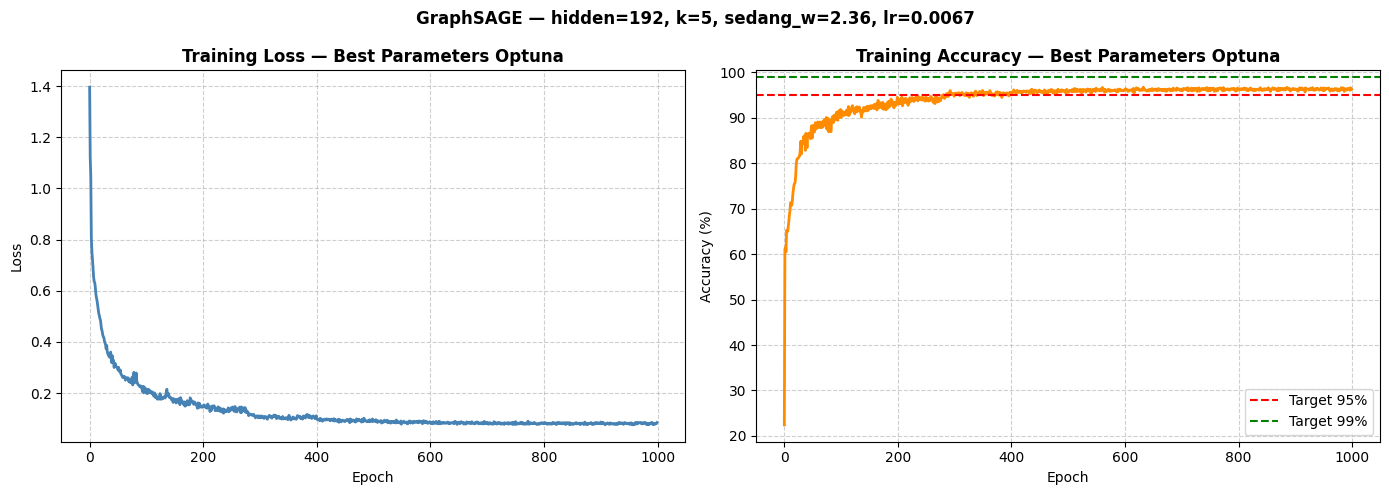

Best Training Loss : 0.0760
Best Training Acc  : 96.44%


In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses_best, linewidth=2, color='steelblue')
axes[0].set_title('Training Loss — Best Parameters Optuna', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot([a*100 for a in accs_best], linewidth=2, color='darkorange')
axes[1].axhline(y=95, color='red',   linestyle='--', lw=1.5, label='Target 95%')
axes[1].axhline(y=99, color='green', linestyle='--', lw=1.5, label='Target 99%')
axes[1].set_title('Training Accuracy — Best Parameters Optuna', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle(
    f'GraphSAGE — hidden=192, k=5, sedang_w=2.36, lr=0.0067',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('grafik_training_best_optuna.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Best Training Loss : {best_loss_b:.4f}')
print(f'Best Training Acc  : {best_acc_b*100:.2f}%')


HASIL EVALUASI — BEST PARAMETERS DARI OPTUNA
Accuracy  : 95.99%
Precision : 0.9614
Recall    : 0.9599
F1-Score  : 0.9600
ROC-AUC   : 0.9964

F1 per Kelas:
  Rendah : 0.9821
  Sedang : 0.9522  ← target utama
  Tinggi : 0.9494

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.99      0.97      0.98       592
      Sedang       0.92      0.98      0.95       800
      Tinggi       0.98      0.92      0.95       653

    accuracy                           0.96      2045
   macro avg       0.97      0.96      0.96      2045
weighted avg       0.96      0.96      0.96      2045



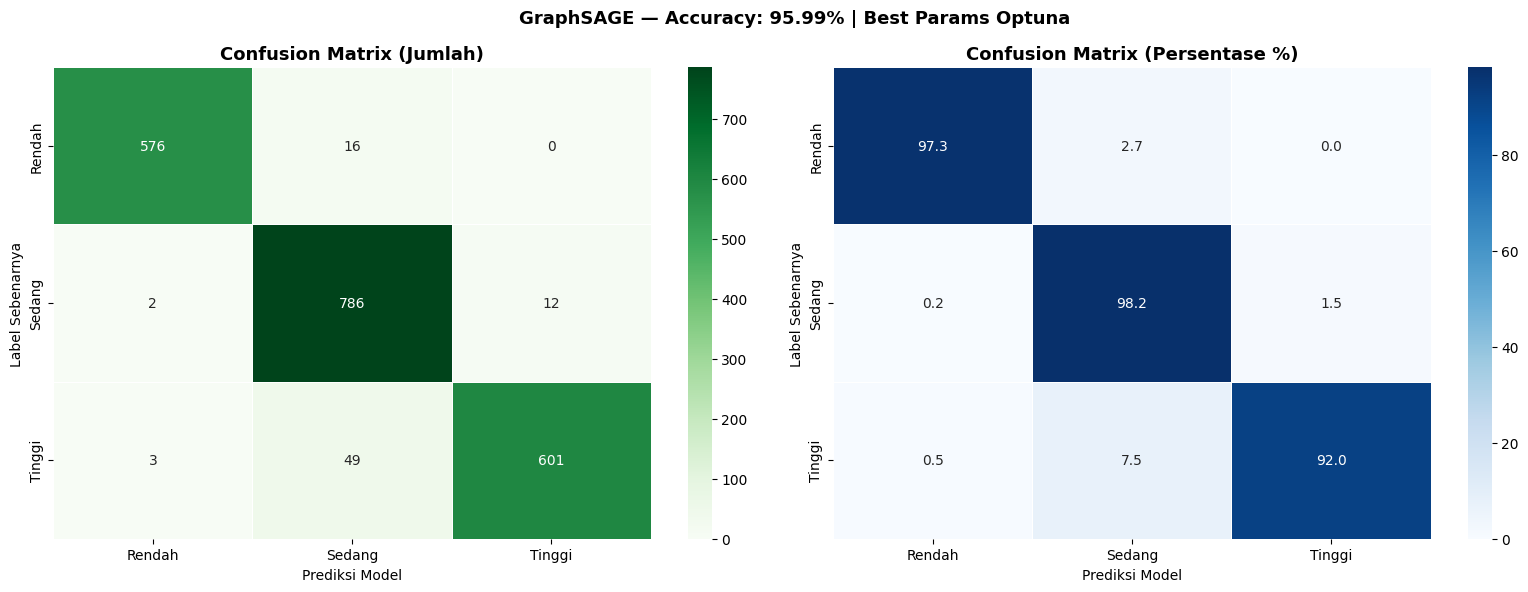

In [42]:
import numpy as np, torch, torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import seaborn as sns, matplotlib.pyplot as plt

y_pred_best, y_prob_best = predict_with_graph(
    model_best, X_te_best.values, X_tr_best.values,
    k=BEST_PARAMS['k_neighbors']
)

acc_b  = accuracy_score(y_te_best, y_pred_best)
prec_b = precision_score(y_te_best, y_pred_best, average='weighted')
rec_b  = recall_score(y_te_best, y_pred_best, average='weighted')
f1_b   = f1_score(y_te_best, y_pred_best, average='weighted')
auc_b  = roc_auc_score(y_te_best, y_prob_best, multi_class='ovr', average='weighted')
f1_per = f1_score(y_te_best, y_pred_best, average=None, zero_division=0)

print('=' * 65)
print('HASIL EVALUASI — BEST PARAMETERS DARI OPTUNA')
print('=' * 65)
print(f'Accuracy  : {acc_b*100:.2f}%')
print(f'Precision : {prec_b:.4f}')
print(f'Recall    : {rec_b:.4f}')
print(f'F1-Score  : {f1_b:.4f}')
print(f'ROC-AUC   : {auc_b:.4f}')
print(f'\nF1 per Kelas:')
print(f'  Rendah : {f1_per[0]:.4f}')
print(f'  Sedang : {f1_per[1]:.4f}  ← target utama')
print(f'  Tinggi : {f1_per[2]:.4f}')

target_names = ['Rendah','Sedang','Tinggi']
print('\nClassification Report:')
print(classification_report(y_te_best, y_pred_best, target_names=target_names))

# Confusion Matrix ganda
cm = confusion_matrix(y_te_best, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (Jumlah)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Label Sebenarnya')

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Confusion Matrix (Persentase %)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prediksi Model')
axes[1].set_ylabel('Label Sebenarnya')

plt.suptitle(
    f'GraphSAGE — Accuracy: {acc_b*100:.2f}% | Best Params Optuna',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrix_best_optuna.png', dpi=300, bbox_inches='tight')
plt.show()


### Apa Output yang Dihasilkan Model GNN Ini?

`GraphSAGE.forward()` menghasilkan **logits** berukuran `(jumlah_node, 3)` — satu baris per orang (node), 3 kolom untuk skor kelas Rendah/Sedang/Tinggi. Setelah `softmax` (dilakukan di `predict_with_graph`), ini jadi **distribusi probabilitas** (jumlah tiap baris = 1), dan kelas prediksi = `argmax`-nya. Itulah yang dipakai untuk `accuracy_score`, `confusion_matrix`, dst.

Selain itu, `GraphSAGE.get_embeddings()` mengambil keluaran **sebelum layer klasifikasi terakhir** — sebuah vektor laten `hidden_dim // 2` dimensi per node. Vektor ini bukan probabilitas, tapi "posisi" tiap orang dalam ruang representasi yang sudah menyerap informasi dari tetangga-tetangganya (hasil 3 layer agregasi SAGEConv). Karena dimensinya tinggi, embedding ini diproyeksikan ke 2D (PCA/t-SNE) di sel berikut agar bisa dilihat langsung — idealnya titik-titik dengan warna kelas yang sama akan mengelompok, menunjukkan model berhasil memisahkan pola gaya hidup tiap kategori risiko.


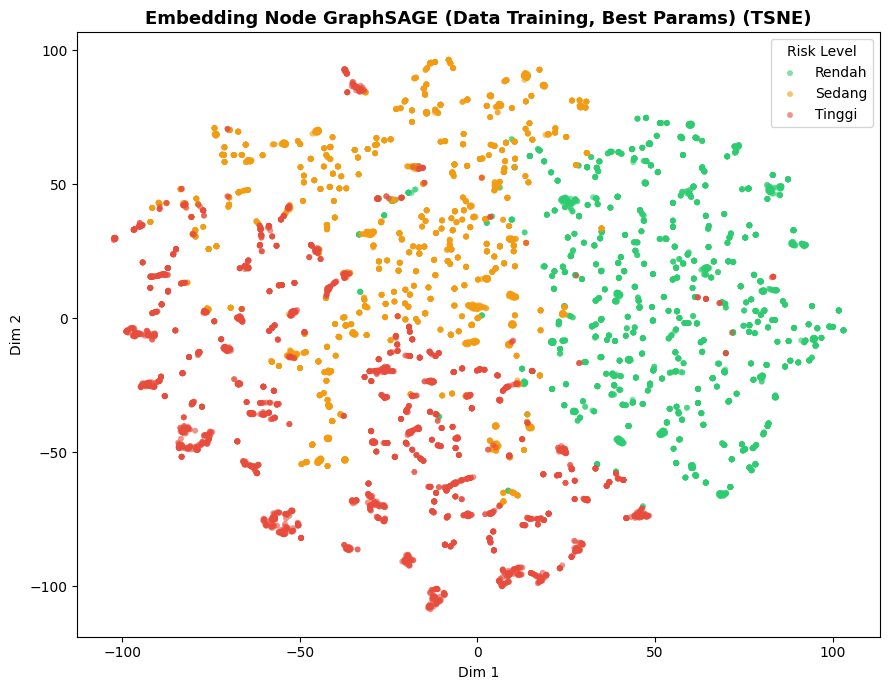

In [43]:
# ============================================================
# VISUALISASI NODE — Embedding Laten Model GraphSAGE (get_embeddings)
# Proyeksi ke 2D (t-SNE / PCA) untuk melihat bagaimana model
# mengelompokkan node menurut tingkat risikonya.
# ============================================================
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visualize_node_embeddings(model, X_arr, y_arr, k=5, method='tsne',
                               title='Visualisasi Embedding Node GraphSAGE'):
    model.eval()
    edge_idx, _ = build_knn_graph(X_arr, k=k)
    x_tensor = torch.tensor(X_arr, dtype=torch.float32)

    with torch.no_grad():
        emb = model.get_embeddings(x_tensor, edge_idx).cpu().numpy()

    reducer = PCA(n_components=2, random_state=42) if method == 'pca' else \
              TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
    emb_2d = reducer.fit_transform(emb)

    target_names = ['Rendah', 'Sedang', 'Tinggi']
    colors = ['#2ecc71', '#f39c12', '#e74c3c']

    plt.figure(figsize=(9, 7))
    for i, cls in enumerate(target_names):
        mask = y_arr == i
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=colors[i], label=cls, alpha=0.6, s=18, edgecolors='none')
    plt.legend(title='Risk Level')
    plt.title(f'{title} ({method.upper()})', fontsize=13, fontweight='bold')
    plt.xlabel('Dim 1'); plt.ylabel('Dim 2')
    plt.tight_layout()
    plt.savefig(f'node_embedding_{method}.png', dpi=300, bbox_inches='tight')
    plt.show()
    return emb, emb_2d

# Embedding pada data training (graf sama seperti yang dipakai saat training)
emb_train, emb_train_2d = visualize_node_embeddings(
    model_best, X_tr_best.values, y_tr_best.values,
    k=BEST_PARAMS['k_neighbors'], method='tsne',
    title='Embedding Node GraphSAGE (Data Training, Best Params)'
)


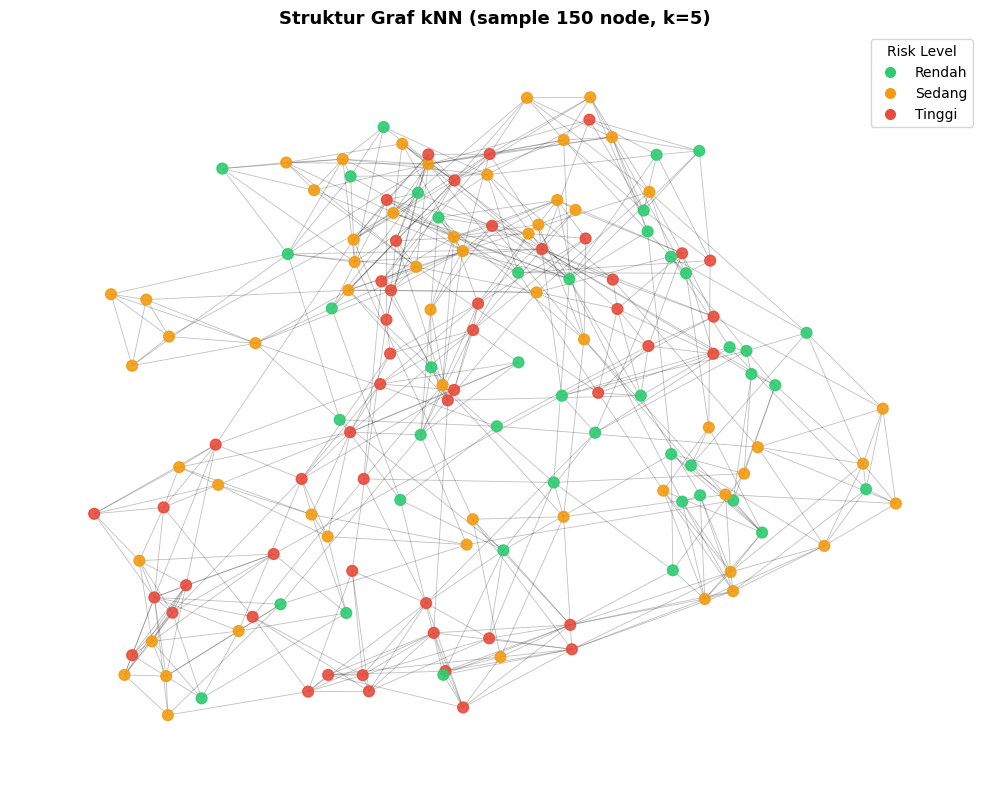

Node: 150 | Edge: 535 | Rata-rata derajat: 7.13


In [44]:
# ============================================================
# VISUALISASI NODE — Struktur Graf kNN (sample node & edge)
# Menunjukkan bentuk graf yang benar-benar dipakai GraphSAGE:
# node = individu, edge = kemiripan cosine antar fitur gaya hidup.
# ============================================================
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def visualize_knn_graph_sample(X_arr, y_arr, k=5, n_sample=150, seed=42,
                                title='Struktur Graf kNN'):
    rng = np.random.default_rng(seed)
    n_sample = min(n_sample, len(X_arr))
    idx_sample = rng.choice(len(X_arr), size=n_sample, replace=False)
    X_sample = X_arr[idx_sample]
    y_sample = np.asarray(y_arr)[idx_sample]

    edge_idx, _ = build_knn_graph(X_sample, k=k)
    edges = edge_idx.t().numpy()

    G = nx.Graph()
    for i in range(len(X_sample)):
        G.add_node(i, label=int(y_sample[i]))
    G.add_edges_from(edges.tolist())

    target_names = ['Rendah', 'Sedang', 'Tinggi']
    colors_map = ['#2ecc71', '#f39c12', '#e74c3c']
    node_colors = [colors_map[G.nodes[n]['label']] for n in G.nodes()]

    pos = nx.spring_layout(G, seed=seed, k=0.3)
    plt.figure(figsize=(10, 8))
    nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=60, alpha=0.9)
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                           markersize=9, label=t)
               for c, t in zip(colors_map, target_names)]
    plt.legend(handles=handles, title='Risk Level')
    plt.title(f'{title} (sample {len(X_sample)} node, k={k})', fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('graph_structure_sample.png', dpi=300, bbox_inches='tight')
    plt.show()

    avg_deg = 2 * G.number_of_edges() / G.number_of_nodes()
    print(f'Node: {G.number_of_nodes()} | Edge: {G.number_of_edges()} | Rata-rata derajat: {avg_deg:.2f}')
    return G

G_sample = visualize_knn_graph_sample(
    X_tr_best.values, y_tr_best.values, k=BEST_PARAMS['k_neighbors']
)


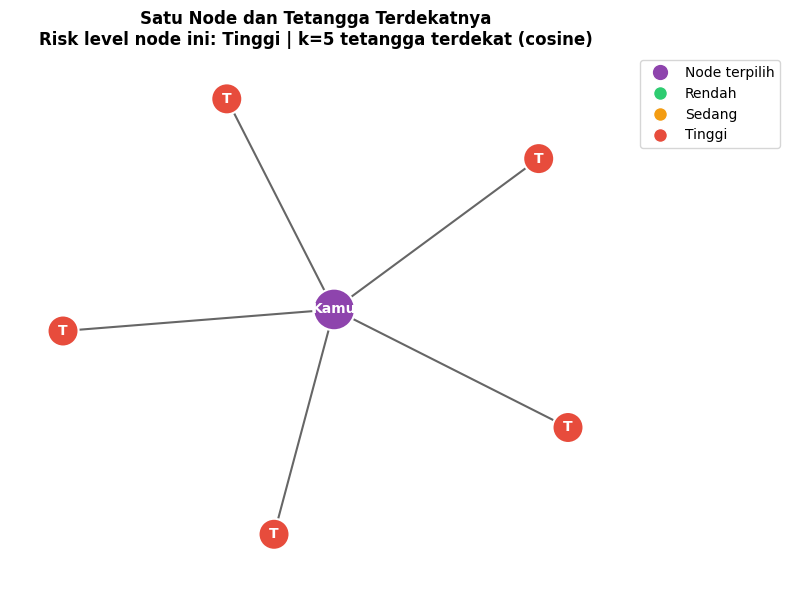

Node terpilih (index 0) - Risk level: Tinggi
Tetangga terdekatnya (index): [1218, 9319, 4507, 1403, 9501]
Risk level tiap tetangga:
  Node 1218: Tinggi
  Node 9319: Tinggi
  Node 4507: Tinggi
  Node 1403: Tinggi
  Node 9501: Tinggi


In [45]:
# ============================================================
# VISUALISASI NODE & EDGE — Contoh 1 Orang dan Tetangga Terdekatnya
# (versi sederhana: fokus ke SATU node, biar gampang dijelaskan ke dosen)
# ============================================================
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

def visualize_single_node_and_neighbors(X_arr, y_arr, node_idx=0, k=5, seed=42,
                                         title='Satu Node dan Tetangga Terdekatnya'):
    X_arr = np.asarray(X_arr)
    y_arr = np.asarray(y_arr)

    # Cari k tetangga terdekat untuk node_idx, pakai metric sama seperti build_knn_graph (cosine)
    knn = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
    knn.fit(X_arr)
    _, indices = knn.kneighbors(X_arr[node_idx:node_idx + 1])
    neighbor_idx = indices[0][1:]  # index 0 dibuang karena itu dirinya sendiri

    G = nx.Graph()
    G.add_node(node_idx, label=int(y_arr[node_idx]))
    for n in neighbor_idx:
        G.add_node(n, label=int(y_arr[n]))
        G.add_edge(node_idx, n)

    target_names = ['Rendah', 'Sedang', 'Tinggi']
    colors_map   = ['#2ecc71', '#f39c12', '#e74c3c']

    pos = nx.spring_layout(G, seed=seed, k=0.8)
    node_colors = [colors_map[G.nodes[n]['label']] if n != node_idx else '#8e44ad' for n in G.nodes()]
    node_sizes  = [900 if n == node_idx else 500 for n in G.nodes()]

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.6)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                            edgecolors='white', linewidths=1.5)
    labels = {node_idx: 'Kamu'}
    labels.update({n: target_names[G.nodes[n]['label']][0] for n in neighbor_idx})
    nx.draw_networkx_labels(G, pos, labels=labels, font_color='white', font_weight='bold', font_size=10)

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#8e44ad',
                           markersize=12, label='Node terpilih')]
    handles += [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=t)
                for c, t in zip(colors_map, target_names)]
    plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.title(f'{title}\nRisk level node ini: {target_names[int(y_arr[node_idx])]} | '
              f'k={k} tetangga terdekat (cosine)', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('single_node_neighbors.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f'Node terpilih (index {node_idx}) - Risk level: {target_names[int(y_arr[node_idx])]}')
    print(f'Tetangga terdekatnya (index): {neighbor_idx.tolist()}')
    print('Risk level tiap tetangga:')
    for n in neighbor_idx:
        print(f'  Node {n}: {target_names[int(y_arr[n])]}')

# Ganti node_idx dengan index orang mana pun yang mau kamu tunjukkan
visualize_single_node_and_neighbors(
    X_tr_best.values, y_tr_best.values, node_idx=0, k=BEST_PARAMS['k_neighbors']
)

### Kenapa Hyperparameter Ini yang Dipilih?

Kombinasi hyperparameter hasil tuning Optuna (Trial #42) dipilih karena beberapa alasan yang saling melengkapi:

| Parameter | Pilihan | Alasan |
|---|---|---|
| **Kapasitas model** | `hidden_dim = 192` | Cukup besar untuk menangkap pola non-linear antar fitur gaya hidup yang kompleks, tanpa membuat model terlalu berat. |
| **Regularisasi** | `dropout = 0.159` | Data latih sudah cukup banyak berkat augmentasi (2500/kelas + ekstra kelas Sedang), jadi risiko overfitting relatif kecil — dropout yang terlalu tinggi justru menghambat model belajar pola halus. |
| **Kecepatan belajar** | `lr = 0.0067` | Membuat konvergensi ke loss minimum lebih cepat dalam anggaran epoch/`patience` yang tersedia, dibantu `ReduceLROnPlateau` agar tetap stabil menjelang akhir training. |
| **Data untuk kelas ambigu** | augmentasi Sedang +1000 ekstra | Kelas **Sedang** (Overweight I & II) paling gampang tertukar ke Rendah *atau* Tinggi karena polanya di "zona abu-abu". Variasi data sintetis ekstra untuk kelas ini membantu model mengenali batas kelasnya lebih baik. |
| **Loss berbobot** | `sedang_weight = 2.363x` | Model "dipaksa" lebih fokus mengoreksi kesalahan pada kelas Sedang, karena kesalahan di kelas ini di-*penalti* 2.36x lebih besar dibanding Rendah/Tinggi saat backpropagation. |

Parameter `k_neighbors` tetap 5 — struktur graf kNN tidak diubah, sehingga peningkatan performa murni berasal dari kombinasi **kapasitas model + regularisasi + learning rate** yang pas, ditambah **strategi data** (augmentasi & class weight) yang menyasar langsung titik terlemah model, yaitu kelas Sedang.


In [46]:
import torch, joblib

torch.save(model_best.state_dict(), 'model_gnn_best.pth')
joblib.dump(scaler_best, 'scaler_best.pkl')
joblib.dump(le_best,     'label_encoder_best.pkl')
joblib.dump(BEST_PARAMS, 'best_params.pkl')

print('Semua file tersimpan!')
print('  model_gnn_best.pth')
print('  scaler_best.pkl')
print('  label_encoder_best.pkl')
print('  best_params.pkl')


Semua file tersimpan!
  model_gnn_best.pth
  scaler_best.pkl
  label_encoder_best.pkl
  best_params.pkl


In [47]:
df_final.to_csv('df_final_smote.csv', index=False)

In [49]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import uuid
from datetime import datetime

# FIX: sejak fitur kategorikal di-ONE-HOT saat training (bukan lagi
# LabelEncoder ordinal 0/1/2), kolom di X_tr_best sekarang bukan lagi
# 'jenis_kelamin', 'kat_konsum_alkohol', dst satu-satu, tapi terpecah jadi
# banyak kolom seperti 'jenis_kelamin_Female', 'jenis_kelamin_Male',
# 'kat_konsum_alkohol_Sometimes', dst. Kalau input manual masih disusun
# sebagai MAP_GENDER/MAP_YESNO/... (angka tunggal per kolom) seperti versi
# lama, baris ini akan ERROR (KeyError / jumlah kolom tidak cocok) karena
# nama kolom yang diminta model sudah beda. Perbaikannya: input kategorikal
# disimpan sebagai STRING asli, lalu di-one-hot dengan cara yang SAMA PERSIS
# seperti saat training, baru diselaraskan (reindex) ke urutan & jumlah
# kolom training (kolom yang tidak muncul di input otomatis diisi 0).
OPSI_GENDER    = ['Female', 'Male']
OPSI_YESNO     = ['no', 'yes']
OPSI_FREQ      = ['Always', 'Frequently', 'Sometimes', 'no']
OPSI_TRANSPORT = ['Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking']

FEATURE_ORDER = list(X_tr_best.columns)   # urutan & nama kolom (termasuk one-hot) hasil training
print("Urutan fitur yang dipakai model:", FEATURE_ORDER)

def input_angka(prompt, tipe=float, minval=None, maxval=None):
    while True:
        try:
            val = tipe(input(prompt))
            if minval is not None and val < minval:
                raise ValueError
            if maxval is not None and val > maxval:
                raise ValueError
            return val
        except ValueError:
            batas = f" antara {minval}-{maxval}" if minval is not None else ""
            print(f"  Input tidak valid, coba lagi (harus angka{batas}).")

def input_kategori(prompt, opsi):
    opsi_str = ', '.join(opsi)
    while True:
        val = input(f"{prompt} ({opsi_str}): ").strip()
        if val in opsi:
            return val
        print(f"  Pilihan tidak dikenali. Ketik salah satu: {opsi_str}")

print("=" * 60)
print("SISTEM PREDIKSI RISIKO OBESITAS (GraphSAGE)")
print("=" * 60)
print("Isi data berikut sesuai kondisi kamu:\n")

data = {}
data['umur']                     = input_angka("Umur (tahun): ", int, 14, 100)
data['jenis_kelamin']            = input_kategori("Jenis kelamin", OPSI_GENDER)
data['kat_konsum_alkohol']       = input_kategori("Konsumsi alkohol", OPSI_FREQ)
data['kat_makan_berkalori']      = input_kategori("Sering makan makanan tinggi kalori?", OPSI_YESNO)
data['kat_makan_sayur']          = input_angka("Frekuensi makan sayur (1=jarang - 3=sering): ", int, 1, 3)
data['jml_makan_utama']          = input_angka("Jumlah makan besar per hari (1-4): ", int, 1, 4)
data['monitoring_kalori']        = input_kategori("Memantau kalori yang dikonsumsi?", OPSI_YESNO)
data['kat_merokok']              = input_kategori("Merokok?", OPSI_YESNO)
data['jml_konsum_air']           = input_angka("Konsumsi air per hari (1=sedikit - 3=banyak): ", int, 1, 3)
data['riwayat_obesitas']         = input_kategori("Riwayat keluarga overweight?", OPSI_YESNO)
data['frek_aktivitas_fisik']     = input_angka("Frekuensi aktivitas fisik per minggu (0=tidak pernah - 3=sering): ", int, 0, 3)
data['durasi_penggunaan_gadget'] = input_angka("Waktu layar per hari (0=sedikit - 2=banyak): ", int, 0, 2)
data['kat_makan_cemilan']        = input_kategori("Kebiasaan ngemil di luar jam makan", OPSI_FREQ)
data['jenis_transportasi']       = input_kategori("Moda transportasi utama", OPSI_TRANSPORT)

# Susun 1 baris data mentah -> ONE-HOT dgn cara sama persis seperti training
# -> reindex supaya kolomnya identik dengan FEATURE_ORDER (kolom yang tidak
# muncul di input, mis. kategori lain dari fitur yang sama, otomatis diisi 0).
# Pastikan semua one-hot kolom adalah int (0/1) bukan bool (True/False).
X_new_raw_df = pd.DataFrame([data])
X_new_onehot = pd.get_dummies(X_new_raw_df, columns=categorical_cols_X)
X_new_onehot = X_new_onehot.reindex(columns=FEATURE_ORDER, fill_value=0)

# FIX: Pastikan semua kolom boolean hasil get_dummies diubah menjadi int (0/1)
bool_cols_new = X_new_onehot.select_dtypes(include='bool').columns
X_new_onehot[bool_cols_new] = X_new_onehot[bool_cols_new].astype(int)

# Scale HANYA kolom numerik asli (sama seperti saat training),
# kolom one-hot dibiarkan 0/1 apa adanya.
X_new_scaled = X_new_onehot.copy()
X_new_scaled[num_cols_exist] = scaler_best.transform(X_new_onehot[num_cols_exist])

# Prediksi lewat graf — digabung dengan data training, sama seperti predict_with_graph
pred, prob = predict_with_graph(
    model_best, X_new_scaled.values, X_tr_best.values, k=BEST_PARAMS['k_neighbors']
)

target_names   = ['Rendah', 'Sedang', 'Tinggi']
hasil_prediksi = target_names[pred[0]]

# Bentuk record sesuai entitas Prediksi_Risiko pada ERD
prediksi_id  = str(uuid.uuid4())[:8]
tgl_prediksi = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

print("\n" + "=" * 60)
print("HASIL PREDIKSI")
print("=" * 60)
print(f"prediksi_id    : {prediksi_id}")
print(f"tgl_prediksi   : {tgl_prediksi}")
print(f"hasil_prediksi : >>> {hasil_prediksi} <<<\n")
print("Detail probabilitas tiap kelas:")
for i, cls in enumerate(target_names):
    bar = '█' * int(prob[0][i] * 30)
    print(f"  {cls:8s}: {prob[0][i]*100:5.1f}% {bar}")

Urutan fitur yang dipakai model: ['umur', 'kat_makan_sayur', 'jml_makan_utama', 'jml_konsum_air', 'frek_aktivitas_fisik', 'durasi_penggunaan_gadget', 'jenis_kelamin_Female', 'jenis_kelamin_Male', 'kat_konsum_alkohol_Always', 'kat_konsum_alkohol_Frequently', 'kat_konsum_alkohol_Sometimes', 'kat_konsum_alkohol_no', 'kat_makan_berkalori_no', 'kat_makan_berkalori_yes', 'monitoring_kalori_no', 'monitoring_kalori_yes', 'kat_merokok_no', 'kat_merokok_yes', 'riwayat_obesitas_no', 'riwayat_obesitas_yes', 'kat_makan_cemilan_Always', 'kat_makan_cemilan_Frequently', 'kat_makan_cemilan_Sometimes', 'kat_makan_cemilan_no', 'jenis_transportasi_Automobile', 'jenis_transportasi_Bike', 'jenis_transportasi_Motorbike', 'jenis_transportasi_Public_Transportation', 'jenis_transportasi_Walking']
SISTEM PREDIKSI RISIKO OBESITAS (GraphSAGE)
Isi data berikut sesuai kondisi kamu:

Umur (tahun): 21
Jenis kelamin (Female, Male): Female
Konsumsi alkohol (Always, Frequently, Sometimes, no): no
Sering makan makanan tin